In [3]:
import pandas as pd

# Чтение первого листа файла
df = pd.read_excel("Risc4.0.xlsx")
print(df.head())

   АКШ  ПАК  ПМК  ПТК  Аорта  Аблация  Аортовентрикулопластика  Пластика_ЛЖ  \
0    1    0    0    0      0        0                        0            0   
1    1    0    0    0      0        0                        0            0   
2    1    0    0    0      0        0                        0            0   
3    1    0    0    0      0        0                        0            0   
4    1    0    0    0      0        0                        0            0   

   Каротидная_эндартерэктомия  Пол  ...  КДОЛЖ_п  КСОЛЖ_п  УО_п  ДЛА_п  \
0                           0    1  ...    113.0     47.0  66.0   26.0   
1                           0    2  ...    100.0     40.0  60.0   27.0   
2                           0    1  ...    122.0     54.0  68.0   29.0   
3                           0    2  ...    115.0     49.0  66.0   25.0   
4                           0    1  ...    116.0     45.0  71.0   27.0   

   Поверхностная_раневая_инфекция  Глубокая_стернальная_инфекция  \
0           

In [4]:
# Выведем на экран названия столбцов, где число пропусков больше 0.
# Для этого вычислим средний по столбцам результат метода isnull(). Получим долю пропусков в каждом столбце. Умножаем на 100 %.

cols_null_percent = df.isnull().mean() * 100

# находим столбцы, где доля пропусков больше 0, сортируем по убыванию и выводим результат:

cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Интраоп_кровопотеря    39.753086
УО                     37.283951
КСОЛЖ                  36.790123
КДОЛЖ                  36.790123
УО_п                   35.061728
КСОЛЖ_п                34.814815
КДОЛЖ_п                34.814815
Гиперхолестеринемия    24.444444
Глюкоза_до_опер        15.061728
Креатинин_после_оп      6.419753
ДЛА_п                   5.679012
СКФ                     4.691358
Креатинин_до_оп         4.444444
Эндокардит              4.444444
КСРЛЖ_п                 3.950617
КДРЛЖ_п                 3.950617
ФВЛЖ_п                  3.950617
ХСН                     3.703704
ФК_NYHA                 2.716049
Дренажи                 1.975309
ИМТ                     1.728395
Длительность_ИК         1.234568
Пережатие_аорты         0.493827
Продолж_опер            0.493827
ДЛА                     0.493827
КДРЛЖ                   0.246914
ХБП                     0.246914
Курение                 0.246914
КСРЛЖ                   0.246914
ФВЛЖ                    0.246914
dtype: flo

In [5]:
# Доля пропусков по колонкам
null_ratios = df.isnull().sum() / len(df)

# Порог
threshold_ratio = 0.25

# Список колонок для удаления
cols_to_drop = null_ratios[null_ratios > threshold_ratio].index

# Удаление
df_cleaned = df.drop(columns=cols_to_drop)

In [6]:
# Выведем на экран названия столбцов, где число пропусков больше 0.
# Для этого вычислим средний по столбцам результат метода isnull(). Получим долю пропусков в каждом столбце. Умножаем на 100 %.

cols_null_percent = df_cleaned.isnull().mean() * 100

# находим столбцы, где доля пропусков больше 0, сортируем по убыванию и выводим результат:

cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Гиперхолестеринемия    24.444444
Глюкоза_до_опер        15.061728
Креатинин_после_оп      6.419753
ДЛА_п                   5.679012
СКФ                     4.691358
Креатинин_до_оп         4.444444
Эндокардит              4.444444
КСРЛЖ_п                 3.950617
КДРЛЖ_п                 3.950617
ФВЛЖ_п                  3.950617
ХСН                     3.703704
ФК_NYHA                 2.716049
Дренажи                 1.975309
ИМТ                     1.728395
Длительность_ИК         1.234568
ДЛА                     0.493827
Продолж_опер            0.493827
Пережатие_аорты         0.493827
КСРЛЖ                   0.246914
КДРЛЖ                   0.246914
Курение                 0.246914
ХБП                     0.246914
ФВЛЖ                    0.246914
dtype: float64

In [7]:
# Количественные: числовые типы (int, float)
quantitative_vars = ['Глюкоза_до_опер', 'Креатинин_после_оп','ФВЛЖ',
                     'КДРЛЖ_п', 'Креатинин_до_оп', 'КСРЛЖ_п', 'ДЛА_п', 'ФВЛЖ_п', 
                     'СКФ', 'Дренажи', 'Длительность_ИК', 'ДЛА', 'Продолж_опер']

# Порядковые: пока оставляем пустыми — требуют ручной настройки
ordinal_vars = ['Эндокардит', 'ХСН', 'ФК_NYHA', 'Курение', 'ХБП', 'Гиперхолестеринемия']

In [8]:
df_cleaned['ДЛА'].describe()

count    403.000000
mean      38.297767
std       13.403633
min       14.000000
25%       28.000000
50%       35.000000
75%       45.000000
max       85.000000
Name: ДЛА, dtype: float64

In [9]:
df_cleaned.loc[:231, ['КДРЛЖ', 'КСРЛЖ', 'КДРЛЖ_п', 'КСРЛЖ_п']] = \
    df_cleaned.loc[:231, ['КДРЛЖ', 'КСРЛЖ', 'КДРЛЖ_п', 'КСРЛЖ_п']] * 10

In [10]:
for col in quantitative_vars:
    median_val = df_cleaned[col].median()
    df_cleaned[col] = df_cleaned[col].fillna(median_val)

In [11]:
for col in ordinal_vars:
    mode_val = df_cleaned[col].mode()[0]
    df_cleaned[col] = df_cleaned[col].fillna(mode_val)

In [12]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 75 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   АКШ                             405 non-null    int64  
 1   ПАК                             405 non-null    int64  
 2   ПМК                             405 non-null    int64  
 3   ПТК                             405 non-null    int64  
 4   Аорта                           405 non-null    int64  
 5   Аблация                         405 non-null    int64  
 6   Аортовентрикулопластика         405 non-null    int64  
 7   Пластика_ЛЖ                     405 non-null    int64  
 8   Каротидная_эндартерэктомия      405 non-null    int64  
 9   Пол                             405 non-null    int64  
 10  Возраст                         405 non-null    int64  
 11  ИМТ                             398 non-null    float64
 12  Курение                         405 

In [13]:
df_cleaned.describe()

,АКШ,ПАК,ПМК,ПТК,Аорта,Аблация,Аортовентрикулопластика,Пластика_ЛЖ,Каротидная_эндартерэктомия,Пол,...,ФВЛЖ_п,КДРЛЖ_п,КСРЛЖ_п,ДЛА_п,Поверхностная_раневая_инфекция,Глубокая_стернальная_инфекция,Дегисценция_грудины,Пневмоторакс,Пневмония,Смерть
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,...,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,0.664198,0.446914,0.093827,0.103704,0.064198,0.009877,0.002469,0.017284,0.012346,1.269136,...,55.750617,53.553086,37.590123,34.935802,0.041975,0.017284,0.009877,0.024691,0.056790,0.133333
std,0.472854,0.497789,0.291949,0.305253,0.245408,0.099011,0.049690,0.130489,0.110560,0.444059,...,6.895581,6.311648,6.200439,8.166633,0.200781,0.130489,0.099011,0.155375,0.231727,0.340355
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,27.000000,30.000000,22.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,52.000000,50.000000,34.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,57.000000,52.000000,36.000000,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,60.000000,56.000000,40.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,...,85.000000,75.000000,61.000000,65.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
df_cleaned['ИМТ'].describe()

count    398.000000
mean      28.697337
std        5.141697
min        0.000000
25%       25.700000
50%       28.845000
75%       31.700000
max       48.400000
Name: ИМТ, dtype: float64

In [15]:
df_cleaned['Пол'] = df_cleaned['Пол'].replace(2, 0)

In [51]:
df_cleaned['Пол'].value_counts()

Пол
1.0    296
0.0    109
Name: count, dtype: int64

In [16]:
# Создаем словарь соответствия {старое_значение: новое_значение}
mapping = {
    5: 0,  # Нет стенокардии -> 0
    0: 1,  # Бессимптомная ишемия -> 1
    1: 2,  # I ФК -> 2
    2: 3,  # II ФК -> 3
    3: 4,  # III ФК -> 4
    4: 5   # IV ФК -> 5
}

# Применяем трансформацию
df_cleaned['Класс_стенокардии'] = df_cleaned['Класс_стенокардии'].map(mapping)

# Проверка результата
print(df_cleaned['Класс_стенокардии'].value_counts().sort_index())

Класс_стенокардии
0    121
1     11
2     27
3    144
4     97
5      5
Name: count, dtype: int64


In [17]:
import numpy as np
# Условия для классификации
conditions = [
    (df_cleaned['СКФ'] > 85),                          # Категория 0
    (df_cleaned['СКФ'] >= 55) & (df_cleaned['СКФ'] <= 85),     # Категория 1
    (df_cleaned['СКФ'] < 55)                          # Категория 2
]

# Значения, которые будут присвоены согласно условиям
choices = [0, 1, 2]

# Создание новой переменной
df_cleaned['Нарушение_функции_почек'] = np.select(conditions, choices, default=np.nan)

# Проверим результат (выведем первые несколько строк)
print(df_cleaned[['СКФ', 'Нарушение_функции_почек']].head())

# Рекомендуется проверить, нет ли пустых значений (если СКФ было пропущено)
print(df_cleaned['Нарушение_функции_почек'].value_counts().sort_index())

     СКФ  Нарушение_функции_почек
0  105.0                      0.0
1   88.0                      0.0
2  143.0                      0.0
3  137.0                      0.0
4   92.0                      0.0
Нарушение_функции_почек
0.0    146
1.0    218
2.0     41
Name: count, dtype: int64


In [18]:
# Определяем условия на основе ваших критериев
conditions_lv = [
    (df_cleaned['ФВЛЖ'] > 50),                          # Категория 0: Сохранная ФВ
    (df_cleaned['ФВЛЖ'] > 30) & (df_cleaned['ФВЛЖ'] <= 50),     # Категория 1: Умеренно сниженная (31-50)
    (df_cleaned['ФВЛЖ'] > 20) & (df_cleaned['ФВЛЖ'] <= 30),     # Категория 2: Низкая (21-30)
    (df_cleaned['ФВЛЖ'] <= 20)                         # Категория 3: Крайне низкая (<=20)
]

# Соответствующие цифровые метки
choices_lv = [0, 1, 2, 3]

# Создаем новую порядковую переменную
df_cleaned['Функция_ЛЖ'] = np.select(conditions_lv, choices_lv, default=np.nan)

# Преобразуем в целые числа (Int64 позволяет сохранить NaN, если они есть в данных)
df_cleaned['Функция_ЛЖ'] = df_cleaned['Функция_ЛЖ'].astype('Int64')

# Проверка корректности разбиения
print("Распределение пациентов по функции ЛЖ:")
print(df_cleaned['Функция_ЛЖ'].value_counts().sort_index())

Распределение пациентов по функции ЛЖ:
Функция_ЛЖ
0    332
1     73
Name: count, dtype: Int64


In [19]:
# Определяем условия для переменной "ЛГ"
conditions_lh = [
    (df_cleaned['ДЛА'] < 31),                         # Категория 0: Нет ЛГ
    (df_cleaned['ДЛА'] >= 31) & (df_cleaned['ДЛА'] <= 55),    # Категория 1: Умеренная ЛГ
    (df_cleaned['ДЛА'] > 55)                         # Категория 2: Тяжелая ЛГ
]

# Коды категорий
choices_lh = [0, 1, 2]

# Создаем новую переменную в датасете
df_cleaned['ЛГ'] = np.select(conditions_lh, choices_lh, default=np.nan)

# Преобразуем в целочисленный тип (Int64 сохраняет NaN при их наличии)
df_cleaned['ЛГ'] = df_cleaned['ЛГ'].astype('Int64')

# Проверка результата
print("Распределение пациентов по степени ЛГ:")
print(df_cleaned['ЛГ'].value_counts().sort_index())

Распределение пациентов по степени ЛГ:
ЛГ
0    165
1    194
2     46
Name: count, dtype: Int64


In [20]:
# 1. Список бинарных колонок (суррогатов объема)
op_columns = [
    'АКШ', 'ПАК', 'ПМК', 'ПТК', 'Аорта', 'Аблация', 
    'Аортовентрикулопластика', 'Пластика_ЛЖ', 'Каротидная_эндартерэктомия'
]

# Колонки "клапанно-аортального" блока (все, кроме АКШ)
other_ops = [col for col in op_columns if col != 'АКШ']

# 2. Расчет суммарного количества процедур
# Используем .sum(axis=1), чтобы посчитать количество единиц в каждой строке
total_count = df_cleaned[op_columns].sum(axis=1)
other_count = df_cleaned[other_ops].sum(axis=1)

# 3. Логика распределения по категориям (0, 1, 2, 3)
conditions_op = [
    (df_cleaned['АКШ'] == 1) & (other_count == 0),               # Категория 0: Только АКШ
    (df_cleaned['АКШ'] == 0) & (other_count == 1),               # Категория 1: Только 1 из списка (но не АКШ)
    (total_count == 2),                                          # Категория 2: Ровно 2 любых вмешательства
    (total_count >= 3)                                           # Категория 3: 3 и более любых вмешательств
]

choices_op = [0, 1, 2, 3]

# 4. Применение условий к датасету df_cleaned
df_cleaned['Объем_операции'] = np.select(conditions_op, choices_op, default=np.nan)

# Преобразуем в целочисленный тип Int64 (он поддерживает NaN, если есть пустые строки)
df_cleaned['Объем_операции'] = df_cleaned['Объем_операции'].astype('Int64')

# 5. Проверка распределения результатов
print("Распределение пациентов по объему операции в df_cleaned:")
print(df_cleaned['Объем_операции'].value_counts().sort_index())

# Визуальная проверка (первые 5 строк)
print("\nКонтроль вычислений (фрагмент):")
print(df_cleaned[op_columns + ['Объем_операции']].head())

Распределение пациентов по объему операции в df_cleaned:
Объем_операции
0    203
1     80
2     82
3     40
Name: count, dtype: Int64

Контроль вычислений (фрагмент):
   АКШ  ПАК  ПМК  ПТК  Аорта  Аблация  Аортовентрикулопластика  Пластика_ЛЖ  \
0    1    0    0    0      0        0                        0            0   
1    1    0    0    0      0        0                        0            0   
2    1    0    0    0      0        0                        0            0   
3    1    0    0    0      0        0                        0            0   
4    1    0    0    0      0        0                        0            0   

   Каротидная_эндартерэктомия  Объем_операции  
0                           0               0  
1                           0               0  
2                           0               0  
3                           0               0  
4                           0               0  


In [21]:
# Получаем частоты и проценты в виде долей
freq = df_cleaned['ФК_NYHA'].value_counts().sort_index()
perc = df_cleaned['ФК_NYHA'].value_counts(normalize=True).sort_index()

# Объединяем в один DataFrame и переводим доли в проценты
result = pd.DataFrame({
    'Частота': freq,
    'Процент': perc * 100
})

print(result)

         Частота    Процент
ФК_NYHA                    
1.0           33   8.148148
2.0          150  37.037037
3.0          199  49.135802
4.0           23   5.679012


In [22]:
# Фильтруем тех, у кого 'Объем_операции' равен NaN
missing_ops = df_cleaned[df_cleaned['Объем_операции'].isna()]

print(f"Количество пациентов с NaN: {len(missing_ops)}")
print("\nФрагмент данных с NaN (первые 10):")
# Выводим только столбцы операций, чтобы увидеть их "комбинацию"
print(missing_ops[op_columns].head(10))

Количество пациентов с NaN: 0

Фрагмент данных с NaN (первые 10):
Empty DataFrame
Columns: [АКШ, ПАК, ПМК, ПТК, Аорта, Аблация, Аортовентрикулопластика, Пластика_ЛЖ, Каротидная_эндартерэктомия]
Index: []


In [23]:
# Получаем список индексов, где Объем_операции = NaN
nan_indices = df_cleaned[df_cleaned['Объем_операции'].isna()].index.tolist()

print(f"Количество пациентов с NaN: {len(nan_indices)}")
print("Список индексов этих пациентов:")
print(nan_indices)

Количество пациентов с NaN: 0
Список индексов этих пациентов:
[]


In [24]:
df_cleaned.columns

Index(['АКШ', 'ПАК', 'ПМК', 'ПТК', 'Аорта', 'Аблация',
       'Аортовентрикулопластика', 'Пластика_ЛЖ', 'Каротидная_эндартерэктомия',
       'Пол', 'Возраст', 'ИМТ', 'Курение', 'Гиперхолестеринемия', 'СКФ',
       'Креатинин_до_оп', 'Креатинин_после_оп', 'ХБП', 'Глюкоза_до_опер',
       'Эндокардит', 'Диабет', 'ГБ', 'ХОБЛ', 'ОИМ_в_анамнезе',
       'ОНМК_в_анамнезе', 'ЧКВ_ранее', 'Мультифокальный_атеросклероз', 'ИБС',
       'Класс_стенокардии', 'ФК_NYHA', 'ХСН', 'ФВЛЖ', 'КДРЛЖ', 'КСРЛЖ', 'ДЛА',
       'Ствол_ЛКА', 'односос', 'двухсос', 'трехсос', 'Продолж_опер',
       'Длительность_ИК', 'Пережатие_аорты', 'Плегия', 'Доставка_плегии',
       'Количество_шунтов', 'Дренажи', 'Инотропы',
       'Сердечная_недостаточность_1', 'Сердечная_недостаточность_2',
       'Сердечная_недостаточность_3', 'ИВЛ_ч', 'Инотропная_поддержка_ч',
       'Послеоп_ОИМ', 'Пребывание_в_ОРИТ_ч', 'ОНМК',
       'Почечная_недостаточность', 'Печеночная_недостаточность',
       'Дыхательная_недостаточность', 'ДЭП', 

In [25]:
binary_cols = [ 'Курение', 'Гиперхолестеринемия', 'ХБП',  'Эндокардит', 'Диабет', 'ГБ', 'ХОБЛ', 'ОИМ_в_анамнезе', 'ОНМК_в_анамнезе','ЧКВ_ранее', 'Мультифокальный_атеросклероз', 'ИБС']

In [26]:
binary_stats = df_cleaned[binary_cols].agg(['sum', 'mean'])
print(binary_stats)

         Курение  Гиперхолестеринемия        ХБП  Эндокардит    Диабет  \
sum   124.000000           105.000000  51.000000   49.000000  92.00000   
mean    0.306173             0.259259   0.125926    0.120988   0.22716   

              ГБ       ХОБЛ  ОИМ_в_анамнезе  ОНМК_в_анамнезе  ЧКВ_ранее  \
sum   337.000000  21.000000      120.000000        33.000000  80.000000   
mean    0.832099   0.051852        0.296296         0.081481   0.197531   

      Мультифокальный_атеросклероз        ИБС  
sum                      52.000000  289.00000  
mean                      0.128395    0.71358  


In [27]:
# создадим список переменных для euroscore 2
euroscore_vars = ['Возраст', 'Пол', 'ХОБЛ', 'Мультифокальный_атеросклероз', 'Эндокардит', 
                  'Нарушение_функции_почек', 'Диабет', 'Класс_стенокардии', 'Функция_ЛЖ', 
                  'ОИМ_в_анамнезе', 'ЛГ', 'ФК_NYHA', 'Аорта', 'Объем_операции']

График сохранен: dissertation_plots/age_distribution.png


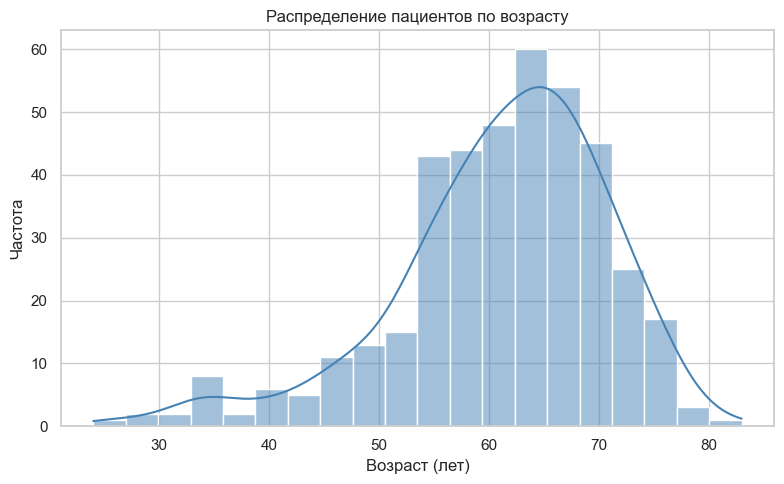

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Blues_d')


График сохранен: dissertation_plots/plot_Нарушение_функции_почек.png


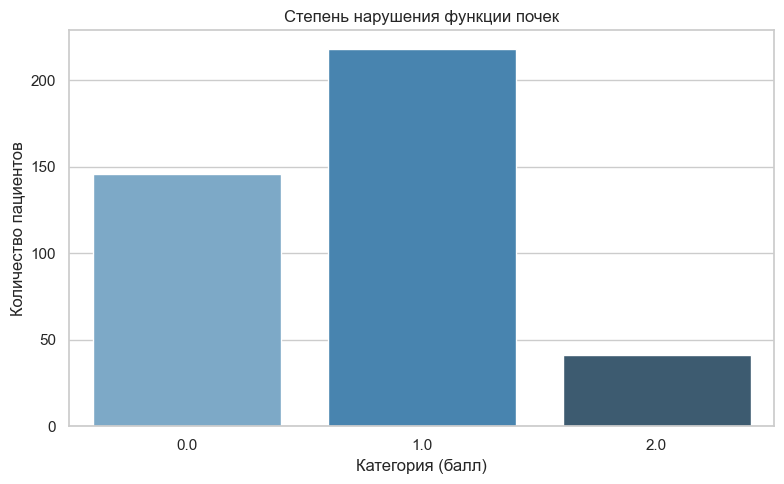

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Blues_d')


График сохранен: dissertation_plots/plot_Класс_стенокардии.png


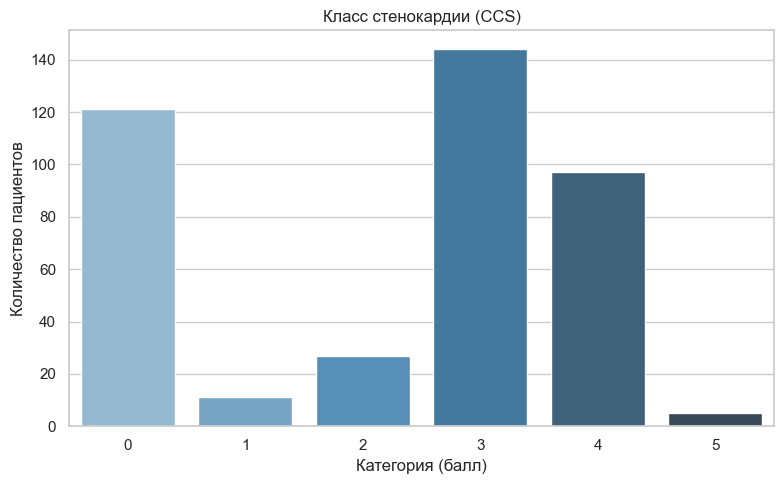

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Blues_d')


График сохранен: dissertation_plots/plot_Функция_ЛЖ.png


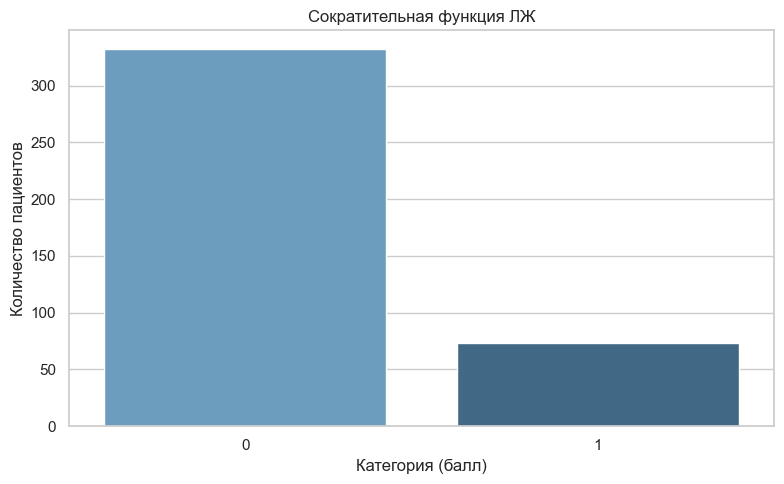

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Blues_d')


График сохранен: dissertation_plots/plot_ЛГ.png


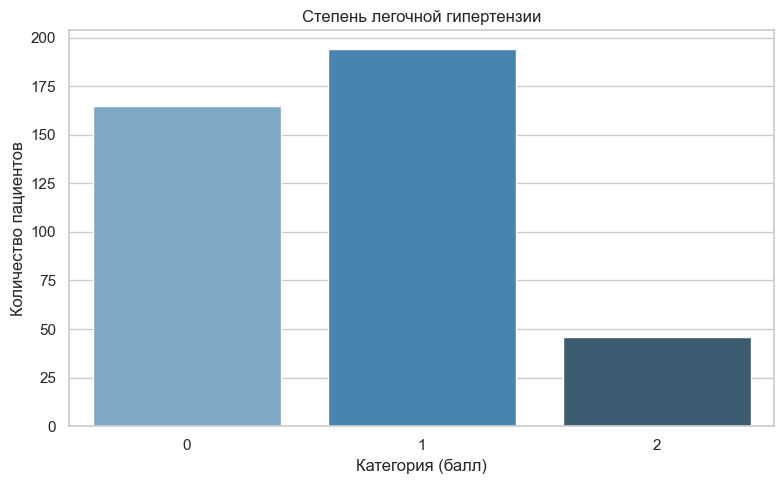

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Blues_d')


График сохранен: dissertation_plots/plot_ФК_NYHA.png


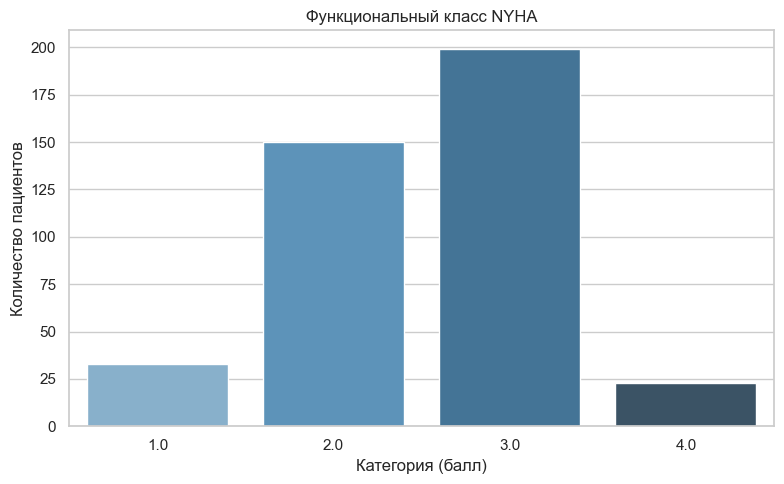

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Blues_d')


График сохранен: dissertation_plots/plot_Объем_операции.png


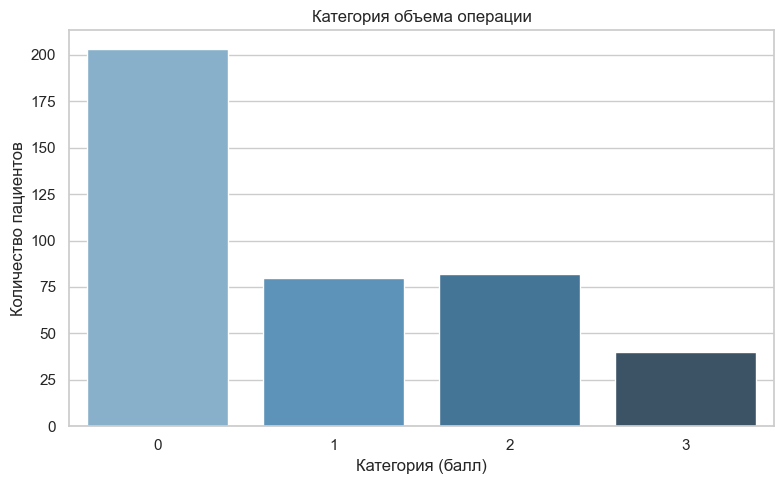

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Pastel1')


График сохранен: dissertation_plots/plot_Пол.png


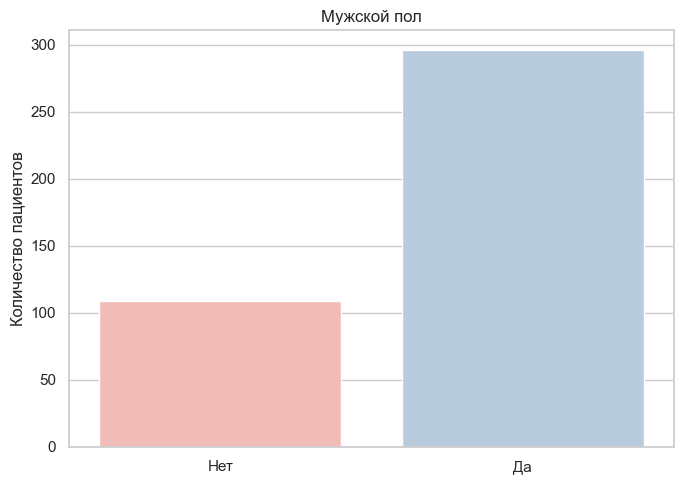

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Pastel1')


График сохранен: dissertation_plots/plot_ХОБЛ.png


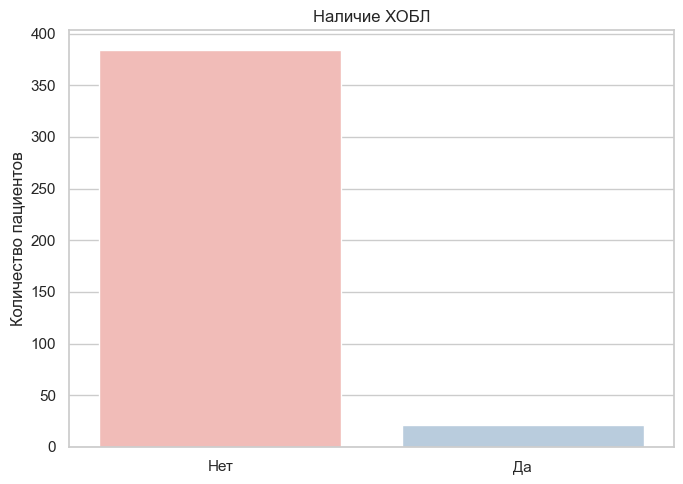

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Pastel1')


График сохранен: dissertation_plots/plot_Мультифокальный_атеросклероз.png


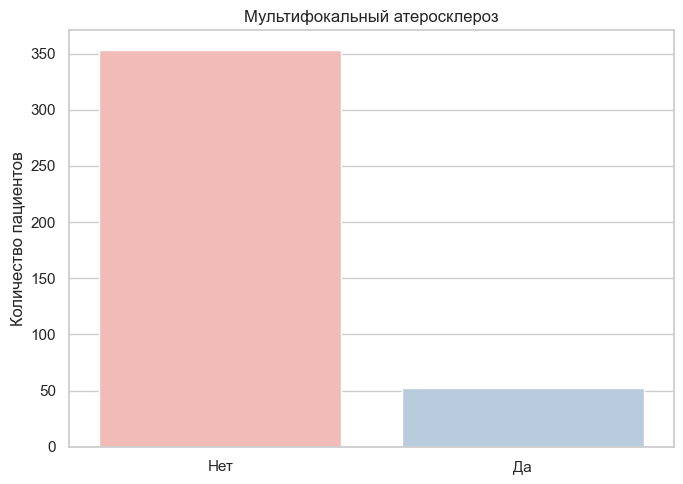

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Pastel1')


График сохранен: dissertation_plots/plot_Эндокардит.png


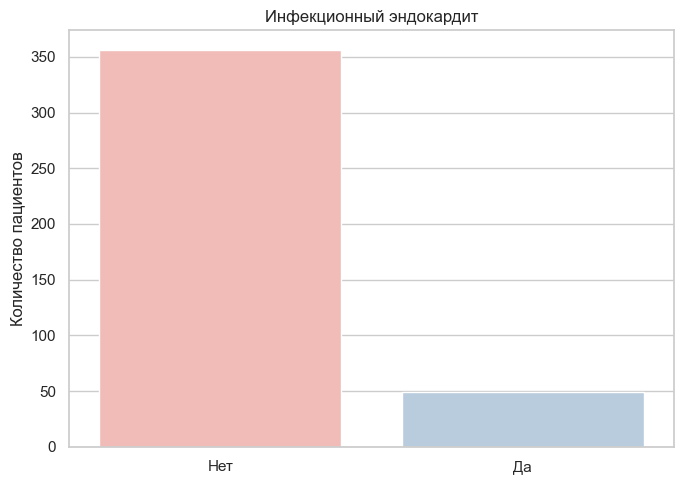

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Pastel1')


График сохранен: dissertation_plots/plot_Диабет.png


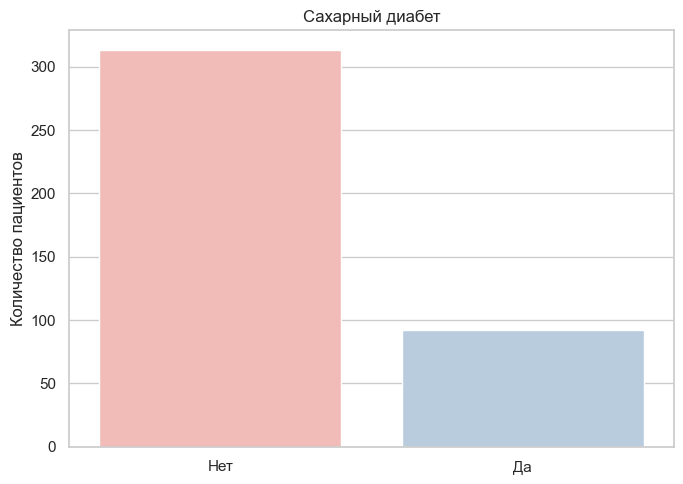

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Pastel1')


График сохранен: dissertation_plots/plot_ОИМ_в_анамнезе.png


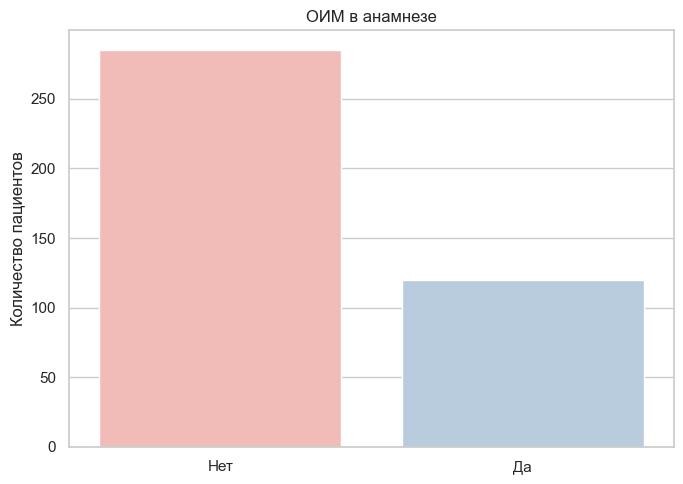

C:\Users\yavis\AppData\Local\Temp\ipykernel_17148\3889374078.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=col, palette='Pastel1')


График сохранен: dissertation_plots/plot_Аорта.png


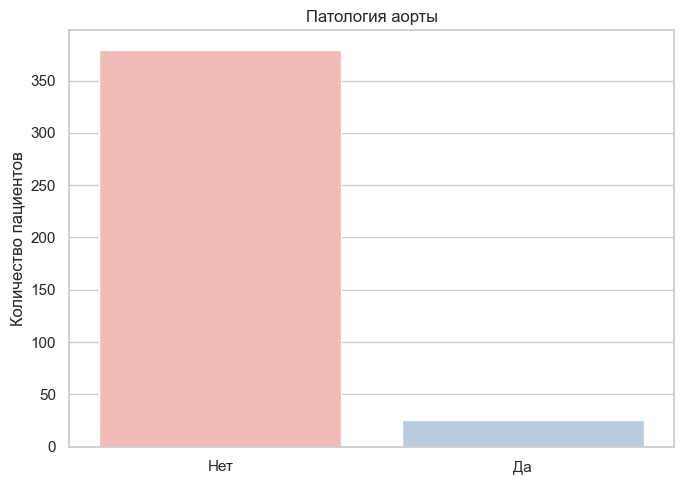

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Создаем папку для графиков, если её нет
if not os.path.exists('dissertation_plots'):
    os.makedirs('dissertation_plots')

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

def save_plot(name):
    plt.tight_layout()
    plt.savefig(f'dissertation_plots/{name}.png', dpi=300, bbox_inches='tight')
    print(f"График сохранен: dissertation_plots/{name}.png")
    plt.show()

# 1. Возраст (Гистограмма)
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['Возраст'], kde=True, color='steelblue', bins=20)
plt.title('Распределение пациентов по возрасту')
plt.xlabel('Возраст (лет)')
plt.ylabel('Частота')
save_plot('age_distribution')

# 2. Категориальные признаки (Порядковые)
cat_features = {
    'Нарушение_функции_почек': 'Степень нарушения функции почек',
    'Класс_стенокардии': 'Класс стенокардии (CCS)',
    'Функция_ЛЖ': 'Сократительная функция ЛЖ',
    'ЛГ': 'Степень легочной гипертензии',
    'ФК_NYHA': 'Функциональный класс NYHA',
    'Объем_операции': 'Категория объема операции'
}

for col, title in cat_features.items():
    plt.figure(figsize=(8, 5))
    # Используем цветовую палитру 'Blues_d' для строгого вида
    sns.countplot(data=df_cleaned, x=col, palette='Blues_d')
    plt.title(title)
    plt.xlabel('Категория (балл)')
    plt.ylabel('Количество пациентов')
    save_plot(f'plot_{col}')

# 3. Номинальные признаки (Бинарные)
bin_features = {
    'Пол': 'Мужской пол',
    'ХОБЛ': 'Наличие ХОБЛ',
    'Мультифокальный_атеросклероз': 'Мультифокальный атеросклероз',
    'Эндокардит': 'Инфекционный эндокардит',
    'Диабет': 'Сахарный диабет',
    'ОИМ_в_анамнезе': 'ОИМ в анамнезе',
    'Аорта': 'Патология аорты'
}

for col, title in bin_features.items():
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df_cleaned, x=col, palette='Pastel1')
    plt.title(title)
    plt.xticks([0, 1], ['Нет', 'Да'])
    plt.xlabel('')
    plt.ylabel('Количество пациентов')
    save_plot(f'plot_{col}')

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Модели машинного обучения
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Инструменты валидации и метрик
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (recall_score, precision_score, f1_score, 
                             roc_auc_score, roc_curve, confusion_matrix)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [30]:
# 1. Приводим все выбранные признаки к типу float
# Это устранит конфликт типов при работе SMOTE
for var in euroscore_vars:
    df_cleaned[var] = df_cleaned[var].astype(float)

# 2. Целевую переменную тоже приводим к обычному int
df_cleaned['Смерть'] = df_cleaned['Смерть'].astype(int)

# 3. Теперь повторяем процесс формирования выборок
df_final = df_cleaned[euroscore_vars + ['Смерть']].dropna()

X = df_final[euroscore_vars]
y = df_final['Смерть']

from sklearn.model_selection import train_test_split

# 1. Сначала отделяем "чистый" тест (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Оставшиеся 80% делим на обучение и валидацию (например, 75/25 от остатка, что даст 60/20 от целого)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print(f"Обучение: {len(X_train)} | Валидация: {len(X_val)} | Тест: {len(X_test)}")
# Теперь можно снова запускать цикл обучения (GridSearchCV)

Обучение: 243 | Валидация: 81 | Тест: 81


In [31]:
print(y_test.value_counts())
print(y_val.value_counts())
print(y_train.value_counts())

Смерть
0    70
1    11
Name: count, dtype: int64
Смерть
0    70
1    11
Name: count, dtype: int64
Смерть
0    211
1     32
Name: count, dtype: int64


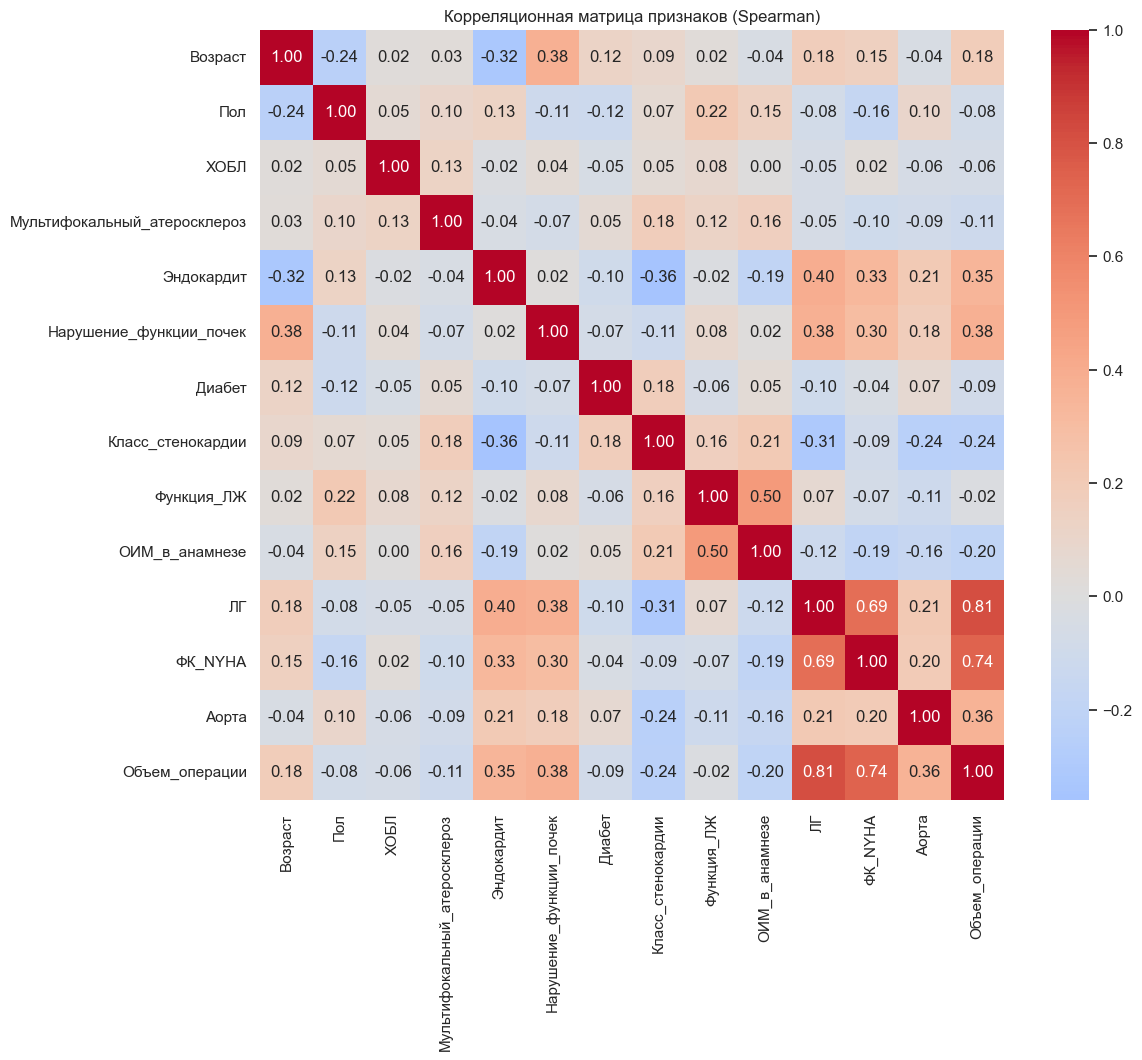

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Считаем корреляцию Спирмена
corr_matrix = X_train.corr(method='spearman')

# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Корреляционная матрица признаков (Spearman)")
plt.show()

In [33]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Наша базовая функция пайплайна
def get_imb_pipeline(clf, scale=False):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('smote', SMOTE(random_state=42))) # k_neighbors подберем внутри сетки
    steps.append(('model', clf))
    return ImbPipeline(steps)

# Умная сетка: расширяем пространство, но контролируем общее число комбинаций
models_config = {
    'ПМ I (LR)': {
        'model': LogisticRegression(max_iter=3000, solver='liblinear', random_state=42),
        'params': {
            # Фокусируемся на жесткой регуляризации (маленькие C), убираем C=5 и 10
            'model__C': [0.005, 0.01, 0.05, 0.1, 0.5, 1.0], 
            'model__penalty': ['l1', 'l2'],
            'smote__k_neighbors': [2, 3, 5]
        },
        'scale': True
    },
    
    'ПМ III (LGBM)': {
        'model': LGBMClassifier(random_state=42, verbose=-1),
        'params': {
            # Уменьшили число итераций (срезали 450) и жестко ограничили рост деревьев
            'model__n_estimators': [100, 150, 200],          
            'model__learning_rate': [0.01, 0.03],      
            'model__num_leaves': [7, 15],                     # Убрали 31 (сокращаем количество терминальных листьев в 2 раза)
            'model__min_child_samples': [15, 20, 30],         # Резко увеличили порог для создания листа (минимум 15-30 пациентов)
            'model__colsample_bytree': [0.6, 0.8],            # Сильнее ограничиваем подмножества признаков
            'model__reg_lambda': [5, 10, 20, 50],             # Мощнейший Ridge-штраф против раздувания весов
            'smote__k_neighbors': [3, 5]
        },
        'scale': False
    },
 
    'ПМ V (XGBoost)': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            # Зажали итерации и уменьшили глубину до строгого диапазона 2-4
            'model__n_estimators': [100, 150, 200],
            'model__learning_rate': [0.01, 0.03],       
            'model__max_depth': [2, 3, 4],                    # Убрали глубину 5, которая уходила в оверфит
            'model__lambda': [5, 10, 20, 50],                 # Резко подняли L2-регуляризацию
            'model__subsample': [0.7, 0.8],                   # Добавили более агрессивный бэггинг по строкам
            'model__colsample_bytree': [0.6, 0.8],            # Бэггинг по колонкам
            'smote__k_neighbors': [3, 5]
        },
        'scale': False
    },
    
    'ПМ II (CatBoost)': {
        'model': CatBoostClassifier(verbose=0, random_state=42, early_stopping_rounds=40),
        'params': {
            # Ограничили глубину рамками 3-5 (убрали глубокую шестерку)
            'model__depth': [3, 4, 5],                        
            'model__l2_leaf_reg': [10, 20, 40, 60],           # Экстремально подняли регуляризацию на листьях
            'model__iterations': [200, 350],                  # Снизили базовый потолок итераций
            'smote__k_neighbors': [3, 5]
        },
        'scale': False
    },
    
    'ПМ IV (RF)': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            # Случайный лес склонен к переобучению при большой глубине, зажимаем её
            'model__n_estimators': [150, 300],                # 500 деревьев избыточны и «запоминают» Train
            'model__max_depth': [3, 5, 7],                    # Срезали глубокие уровни 8 и 10
            'model__min_samples_leaf': [4, 6, 8, 12],         # Лист формируется только если в нем много пациентов
            'model__max_features': ['sqrt', 0.5],             # Ограничение числа признаков на сплит
            'smote__k_neighbors': [3, 5]
        },
        'scale': False
    },
 
    'ПМ VI (SVM)': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            # Убираем огромные штрафы C=10 и 50, которые искривляли границу под шум выборки
            'model__C': [0.05, 0.1, 0.5, 1.0, 2.0],           
            'model__gamma': ['scale', 0.005, 0.01],           # Делаем форму радиальной функции более плавной
            'model__kernel': ['rbf'],
            'smote__k_neighbors': [3, 5]
        },
        'scale': True
    }
}

print("--- СТАРТ УЛУЧШЕННОГО ПРОЦЕССА ОБУЧЕНИЯ (N=~243) ---")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_pms = {}

for name, config in models_config.items():
    print(f"⚙️ Подбираем параметры для {name}...")
    pipeline = get_imb_pipeline(config['model'], scale=config['scale'])
    
    # n_jobs=-1 задействует все ядра CPU в Колабе
    grid = GridSearchCV(pipeline, config['params'], cv=skf, scoring='roc_auc', n_jobs=-1, verbose=1)
    
    grid.fit(X_train, y_train)
    final_pms[name] = grid.best_estimator_
    print(f"✅ {name} готова!")
    print(f"Лучшие параметры: {grid.best_params_}\n" + "-"*40)

--- СТАРТ УЛУЧШЕННОГО ПРОЦЕССА ОБУЧЕНИЯ (N=~243) ---
⚙️ Подбираем параметры для ПМ I (LR)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ ПМ I (LR) готова!
Лучшие параметры: {'model__C': 0.01, 'model__penalty': 'l2', 'smote__k_neighbors': 2}
----------------------------------------
⚙️ Подбираем параметры для ПМ III (LGBM)...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
✅ ПМ III (LGBM) готова!
Лучшие параметры: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__min_child_samples': 20, 'model__n_estimators': 150, 'model__num_leaves': 15, 'model__reg_lambda': 20, 'smote__k_neighbors': 5}
----------------------------------------
⚙️ Подбираем параметры для ПМ V (XGBoost)...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
✅ ПМ V (XGBoost) готова!
Лучшие параметры: {'model__colsample_bytree': 0.8, 'model__lambda': 10, 'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 0.

In [34]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, roc_curve

# Нам понадобится старая функция поиска порога Юдена
def find_best_threshold(model, X, y):
    y_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

optimized_results_dense = []

for name, model in final_pms.items():
    # Порог калибруем строго по валидационной выборке
    best_thresh = find_best_threshold(model, X_val, y_val)
    
    # Метрики считаем строго по независимой тестовой выборке
    y_proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = (y_proba_test >= best_thresh).astype(int)
    
    optimized_results_dense.append({
        'Алгоритм': name,
        'Threshold (from Val)': round(best_thresh, 3),
        'Recall (Test)': recall_score(y_test, y_pred_test),
        'Precision (Test)': precision_score(y_test, y_pred_test),
        'F1 (Test)': f1_score(y_test, y_pred_test),
        'ROC-AUC (Test)': roc_auc_score(y_test, y_proba_test)
    })

opt_df_dense = pd.DataFrame(optimized_results_dense)
print("\n--- СРАВНИТЕЛЬНЫЕ МЕТРИКИ ПОСЛЕ СЛУЧАЙНОЙ ОПТИМИЗАЦИИ СЕТКИ ---")
print(opt_df_dense.sort_values(by='ROC-AUC (Test)', ascending=False).to_string(index=False))


--- СРАВНИТЕЛЬНЫЕ МЕТРИКИ ПОСЛЕ СЛУЧАЙНОЙ ОПТИМИЗАЦИИ СЕТКИ ---
        Алгоритм  Threshold (from Val)  Recall (Test)  Precision (Test)  F1 (Test)  ROC-AUC (Test)
      ПМ IV (RF)                 0.395       0.727273          0.320000   0.444444        0.849351
   ПМ III (LGBM)                 0.299       0.727273          0.296296   0.421053        0.842857
  ПМ V (XGBoost)                 0.294       0.727273          0.296296   0.421053        0.832468
     ПМ VI (SVM)                 0.183       0.727273          0.320000   0.444444        0.828571
       ПМ I (LR)                 0.498       0.909091          0.277778   0.425532        0.820779
ПМ II (CatBoost)                 0.342       0.727273          0.380952   0.500000        0.818182



--- ШАГ 9: РАСЧЕТ И ВИЗУАЛИЗАЦИЯ ROC-КРИВЫХ ДЛЯ ВСЕХ МОДЕЛЕЙ (TEST) ---
📊 Сводный график ROC-кривых успешно сохранен как 'all_models_roc_auc_curve.png'


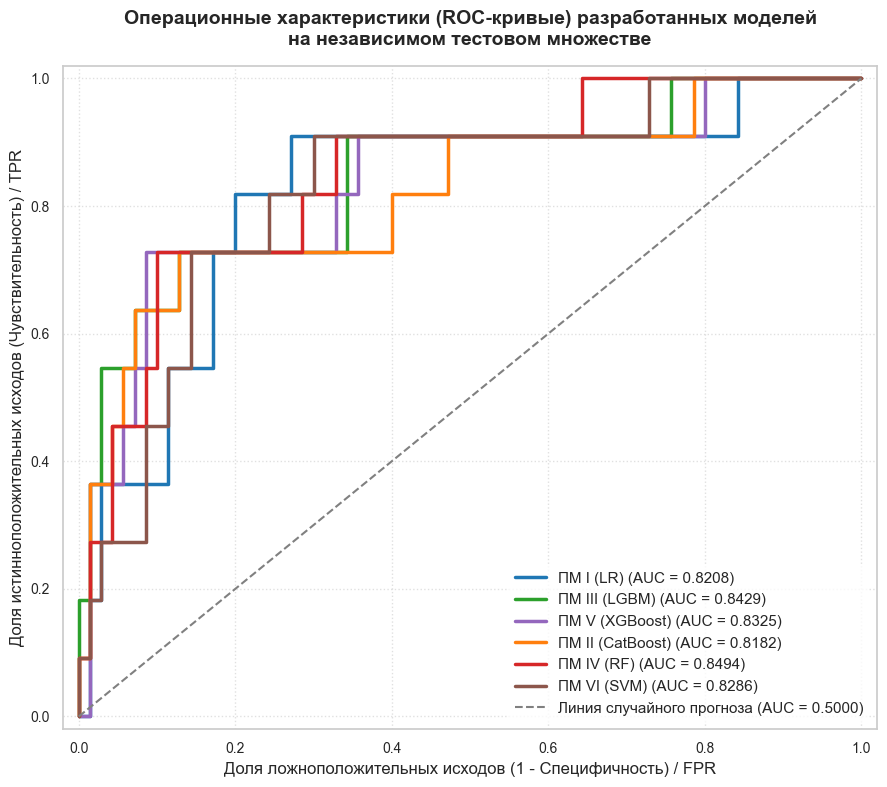

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Настройка академического стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11
})

print("\n" + "="*80)
print("--- ШАГ 9: РАСЧЕТ И ВИЗУАЛИЗАЦИЯ ROC-КРИВЫХ ДЛЯ ВСЕХ МОДЕЛЕЙ (TEST) ---")
print("="*80)

# Цветовая палитра для моделей (чтобы графики легко различались)
colors = {
    'ПМ I (LR)': '#1f77b4',       # Синий
    'ПМ II (CatBoost)': '#ff7f0e', # Оранжевый
    'ПМ III (LGBM)': '#2ca02c',   # Зеленый
    'ПМ IV (RF)': '#d62728',      # Красный
    'ПМ V (XGBoost)': '#9467bd',   # Фиолетовый
    'ПМ VI (SVM)': '#8c564b'       # Коричневый
}

plt.figure(figsize=(9, 8))

# Итерируемся по всем моделям и строим их кривые
for name, model in final_pms.items():
    # Получаем вероятности положительного класса на тестовой выборке
    y_proba_test = model.predict_proba(X_test)[:, 1]
    
    # Вычисляем FPR, TPR и пороги
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    
    # Считаем точную площадь под кривой (AUC)
    roc_auc = auc(fpr, tpr)
    
    # Отрисовываем линию для текущей модели
    plt.plot(
        fpr, 
        tpr, 
        color=colors.get(name, '#7f7f7f'), 
        lw=2.5, 
        label=f'{name} (AUC = {roc_auc:.4f})'
    )

# Отрисовка диагонали случайного угадывания (базовый уровень)
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Линия случайного прогноза (AUC = 0.5000)')

# Настройка осей и подписей (строго по ГОСТу для научных работ)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Доля ложноположительных исходов (1 - Специфичность) / FPR')
plt.ylabel('Доля истинноположительных исходов (Чувствительность) / TPR')
plt.title('Операционные характеристики (ROC-кривые) разработанных моделей\nна независимом тестовом множестве', fontweight='bold', pad=15)

# Располагаем легенду в правом нижнем углу, где она не закрывает кривые
plt.legend(loc="lower right", frameon=True, facecolor='white', edgecolor='none')

# Делаем сетку более аккуратной
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# Сохраняем график в векторе/высоком разрешении для вставки в Word/LaTeX
plot_filename = 'all_models_roc_auc_curve.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"📊 Сводный график ROC-кривых успешно сохранен как '{plot_filename}'")

plt.show()

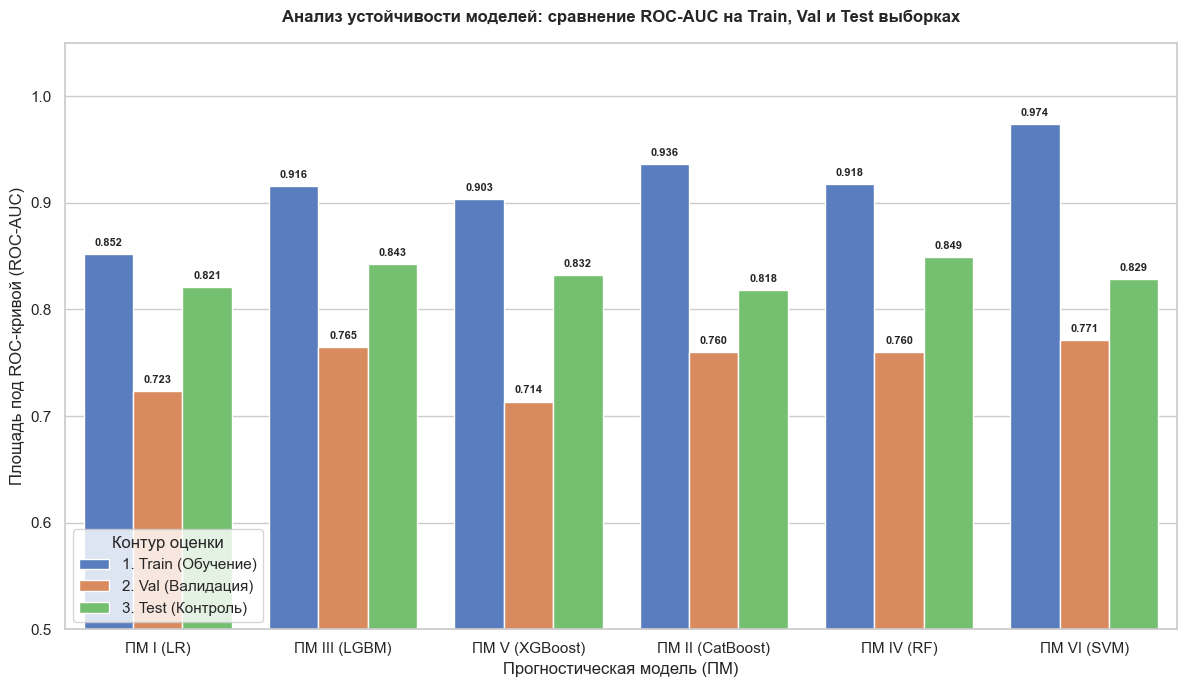

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_auc_score

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

overfitting_data = []

for name, model in final_pms.items():
    # Считаем ROC-AUC на всех трех фронтах
    auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    auc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    # Сохраняем в «длинный» формат для seaborn
    overfitting_data.append({'Алгоритм': name, 'Выборка': '1. Train (Обучение)', 'ROC-AUC': auc_train})
    overfitting_data.append({'Алгоритм': name, 'Выборка': '2. Val (Валидация)', 'ROC-AUC': auc_val})
    overfitting_data.append({'Алгоритм': name, 'Выборка': '3. Test (Контроль)', 'ROC-AUC': auc_test})

df_ovf = pd.DataFrame(overfitting_data)

# Построение сгруппированного барплота
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_ovf, x='Алгоритм', y='ROC-AUC', hue='Выборка', palette='muted')

# Настройка деталей
plt.ylim(0.5, 1.05) # Фокусируемся на зоне значимых значений
plt.title('Анализ устойчивости моделей: сравнение ROC-AUC на Train, Val и Test выборках', fontweight='bold', pad=15)
plt.xlabel('Прогностическая модель (ПМ)')
plt.ylabel('Площадь под ROC-кривой (ROC-AUC)')
plt.legend(title='Контур оценки', loc='lower left')

# Добавим точные значения над барами для диссертационного лоска
for p in ax.patches:
    if p.get_height() > 0: # Проверка на пустые бары легенды
        ax.annotate(f"{p.get_height():.3f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('overfitting_check_plot.png', dpi=300)
plt.show()

In [37]:
import pandas as pd
from sklearn.metrics import roc_auc_score

print("\n" + "="*80)
print("--- ШАГ 10: РАСЧЕТ ROC-AUC НА TRAIN, VAL И TEST С ОЦЕНКОЙ СТАБИЛЬНОСТИ ---")
print("="*80)

rows = []

for name, model in final_pms.items():
    # 1. Считаем вероятности положительного класса для каждого сплита
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_prob_val = model.predict_proba(X_val)[:, 1]
    y_prob_test = model.predict_proba(X_test)[:, 1]
    
    # 2. Вычисляем точные значения ROC-AUC
    auc_train = roc_auc_score(y_train, y_prob_train)
    auc_val = roc_auc_score(y_val, y_prob_val)
    auc_test = roc_auc_score(y_test, y_prob_test)
    
    # 3. Считаем дельту (падение метрики) между Train и Test.
    # Это главный математический индикатор переобучения.
    delta_train_test = auc_train - auc_test
    
    # Сохраняем результаты
    rows.append({
        'Название модели': name,
        'ROC-AUC Train': auc_train,
        'ROC-AUC Val': auc_val,
        'ROC-AUC Test': auc_test,
        'Δ (Train - Test)': delta_train_test
    })

# Создаем и форматируем итоговый DataFrame
df_roc_summary = pd.DataFrame(rows)

print("\n📋 ИТОГОВАЯ ТАБЛИЦА УСТОЙЧИВОСТИ МОДЕЛЕЙ (ROC-AUC):")
print(df_roc_summary.to_string(index=False, formatters={
    'ROC-AUC Train': '{:.4f}'.format,
    'ROC-AUC Val': '{:.4f}'.format,
    'ROC-AUC Test': '{:.4f}'.format,
    'Δ (Train - Test)': '{:.4f}'.format
}))

# Экспортируем в CSV с корректной кодировкой для Excel
df_roc_summary.to_csv('models_roc_auc_stability.csv', index=False, encoding='utf-8-sig')
print("\n💾 Таблица успешно сохранена в файл: 'models_roc_auc_stability.csv'")


--- ШАГ 10: РАСЧЕТ ROC-AUC НА TRAIN, VAL И TEST С ОЦЕНКОЙ СТАБИЛЬНОСТИ ---

📋 ИТОГОВАЯ ТАБЛИЦА УСТОЙЧИВОСТИ МОДЕЛЕЙ (ROC-AUC):
 Название модели ROC-AUC Train ROC-AUC Val ROC-AUC Test Δ (Train - Test)
       ПМ I (LR)        0.8522      0.7234       0.8208           0.0314
   ПМ III (LGBM)        0.9155      0.7649       0.8429           0.0726
  ПМ V (XGBoost)        0.9034      0.7136       0.8325           0.0709
ПМ II (CatBoost)        0.9362      0.7597       0.8182           0.1181
      ПМ IV (RF)        0.9180      0.7597       0.8494           0.0686
     ПМ VI (SVM)        0.9739      0.7714       0.8286           0.1454

💾 Таблица успешно сохранена в файл: 'models_roc_auc_stability.csv'


In [52]:
from sklearn.metrics import brier_score_loss
import pandas as pd

print("="*80)
print("📊 РАСЧЕТ ИНДЕКСА БРАЙЕРА (BRIER SCORE) ДЛЯ ВСЕХ МОДЕЛЕЙ НА ТЕСТЕ")
print("="*80)

# Словарь для сбора результатов
brier_results = {}

# Предполагаем, что X_test_df уже создан на предыдущих шагах (содержит текстовые названия колонок)
# Если нет, раскомментируй строку ниже:
# X_test_df = pd.DataFrame(X_test, columns=X_train.columns) if hasattr(X_train, 'columns') else pd.DataFrame(X_test)

for model_name, pipeline in final_pms.items():
    try:
        # Для линейной модели и SVM внутри пайплайна может быть scaler, 
        # но передача X_test_df безопасна, так как пайплайн сам применит transform.
        
        # Получаем вероятности для класса 1 (риск неблагоприятного исхода)
        y_prob = pipeline.predict_proba(X_test_df)[:, 1]
        
        # Считаем метрику Брайера (y_test — твои истинные метки из тест-выборки)
        brier_val = brier_score_loss(y_test, y_prob)
        
        brier_results[model_name] = round(brier_val, 4)
        print(f"✅ {model_name}: Brier Score = {brier_results[model_name]}")
        
    except Exception as e:
        print(f"❌ Ошибка при расчете для {model_name}: {e}")

# Оформляем результаты в виде датафрейма для вставки в работу
df_brier = pd.DataFrame(list(brier_results.items()), columns=['Прогностическая модель', 'Brier Score'])
df_brier = df_brier.sort_values(by='Brier Score') # Сортируем от лучших (меньших) к худшим

print("\nИТОГОВАЯ ТАБЛИЦА КАЛИБРОВКИ:")
print("-" * 50)
print(df_brier.to_string(index=False))
print("-" * 50)
print("💡 Напоминание: Чем ближе к 0, тем точнее откалиброваны вероятности модели.")

📊 РАСЧЕТ ИНДЕКСА БРАЙЕРА (BRIER SCORE) ДЛЯ ВСЕХ МОДЕЛЕЙ НА ТЕСТЕ
✅ ПМ I (LR): Brier Score = 0.2358
✅ ПМ III (LGBM): Brier Score = 0.1202
✅ ПМ V (XGBoost): Brier Score = 0.1233
✅ ПМ II (CatBoost): Brier Score = 0.1228
✅ ПМ IV (RF): Brier Score = 0.1245
✅ ПМ VI (SVM): Brier Score = 0.1251

ИТОГОВАЯ ТАБЛИЦА КАЛИБРОВКИ:
--------------------------------------------------
Прогностическая модель  Brier Score
         ПМ III (LGBM)       0.1202
      ПМ II (CatBoost)       0.1228
        ПМ V (XGBoost)       0.1233
            ПМ IV (RF)       0.1245
           ПМ VI (SVM)       0.1251
             ПМ I (LR)       0.2358
--------------------------------------------------
💡 Напоминание: Чем ближе к 0, тем точнее откалиброваны вероятности модели.


📈 Фиксация Loss Curve для ПМ II (CatBoost)...
📈 Фиксация Loss Curve для ПМ III (LGBM)...
📈 Фиксация Loss Curve для ПМ V (XGBoost)...


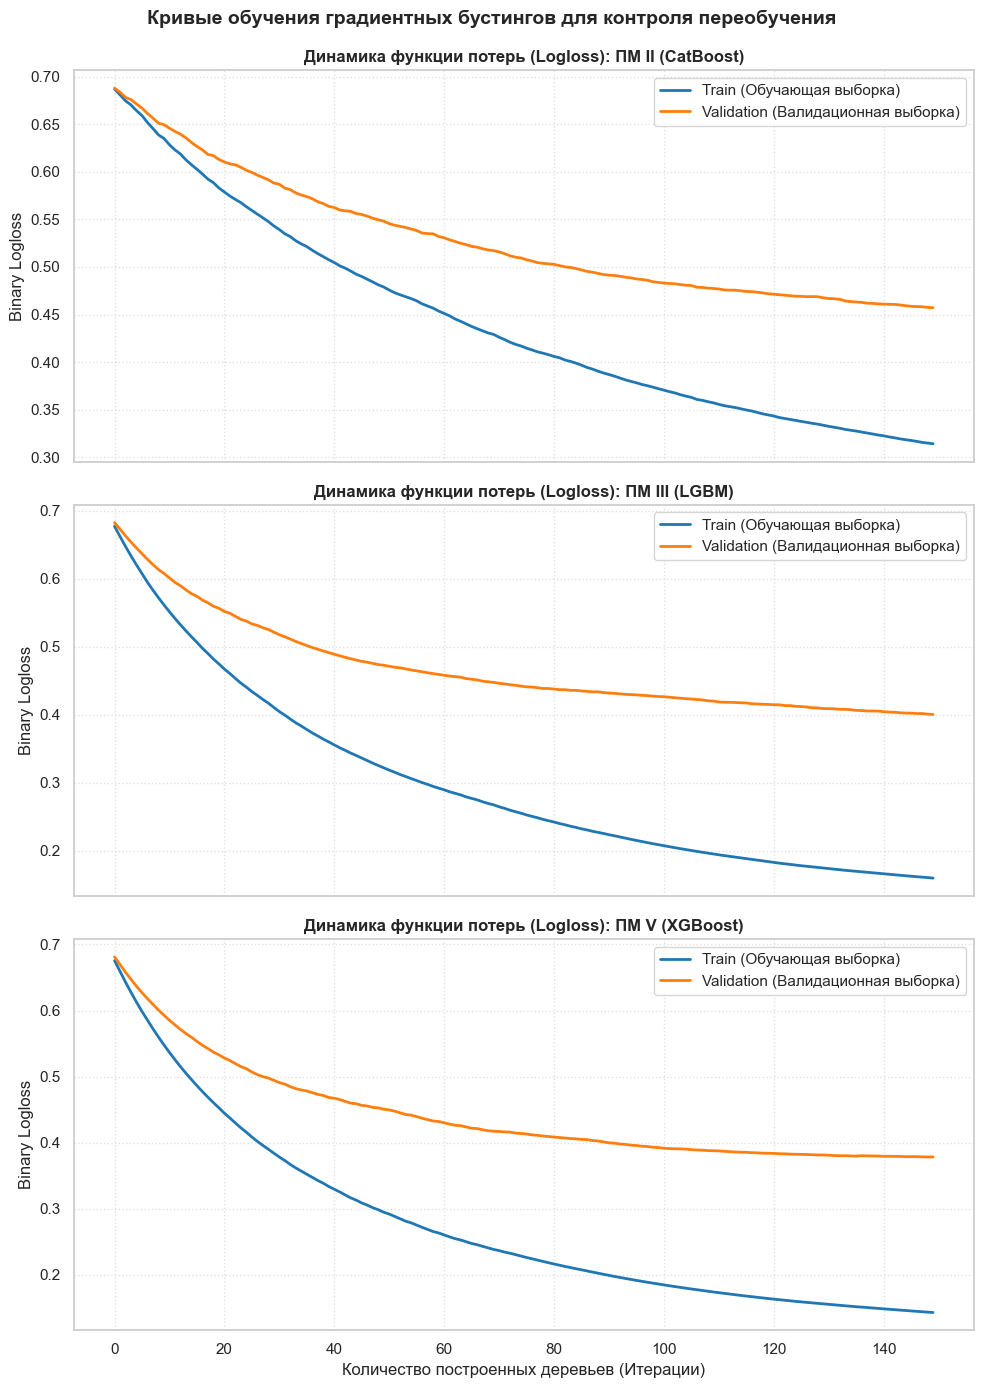

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")

# 1. Готовим данные с SMOTE (как в оригинальном пайплайне)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 2. Инициализируем модели с лучшими гиперпараметрами из GridSearchCV
models_boosting = {
    'ПМ II (CatBoost)': CatBoostClassifier(iterations=150, learning_rate=0.03, depth=6, l2_leaf_reg=15, random_seed=42, verbose=0),
    'ПМ III (LGBM)': LGBMClassifier(n_estimators=150, learning_rate=0.03, num_leaves=15, reg_lambda=5, random_state=42, verbose=-1),
    'ПМ V (XGBoost)': XGBClassifier(n_estimators=150, learning_rate=0.03, max_depth=4, reg_lambda=5, random_state=42, eval_metric='logloss')
}

# 3. Отрисовка сетки графиков 3х1
fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True)

for i, (name, model) in enumerate(models_boosting.items()):
    ax = axes[i]
    print(f"📈 Фиксация Loss Curve для {name}...")
    
    if 'CatBoost' in name:
        model.fit(X_train_res, y_train_res, eval_set=(X_val, y_val), use_best_model=False)
        train_loss = model.get_evals_result()['learn']['Logloss']
        val_loss = model.get_evals_result()['validation']['Logloss']
    elif 'LGBM' in name:
        model.fit(X_train_res, y_train_res, eval_set=[(X_train_res, y_train_res), (X_val, y_val)])
        train_key = 'training' if 'training' in model.evals_result_ else 'valid_0'
        train_loss = model.evals_result_[train_key]['binary_logloss']
        val_loss = model.evals_result_['valid_1']['binary_logloss']
    elif 'XGBoost' in name:
        model.fit(X_train_res, y_train_res, eval_set=[(X_train_res, y_train_res), (X_val, y_val)], verbose=False)
        results = model.evals_result()
        train_loss = results['validation_0']['logloss']
        val_loss = results['validation_1']['logloss']
        
    # Визуализация конкретной модели
    ax.plot(train_loss, label='Train (Обучающая выборка)', color='#1f77b4', lw=2)
    ax.plot(val_loss, label='Validation (Валидационная выборка)', color='#ff7f0e', lw=2)
    ax.set_title(f'Динамика функции потерь (Logloss): {name}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Binary Logloss')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)
        

axes[-1].set_xlabel('Количество построенных деревьев (Итерации)')
plt.suptitle('Кривые обучения градиентных бустингов для контроля переобучения', y=0.99, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boosting_loss_curves.png', dpi=300)
plt.show()

📊 Расчет валидационной кривой для ПМ IV (Random Forest)...
📊 Расчет валидационной кривой для ПМ I (Logistic Regression)...


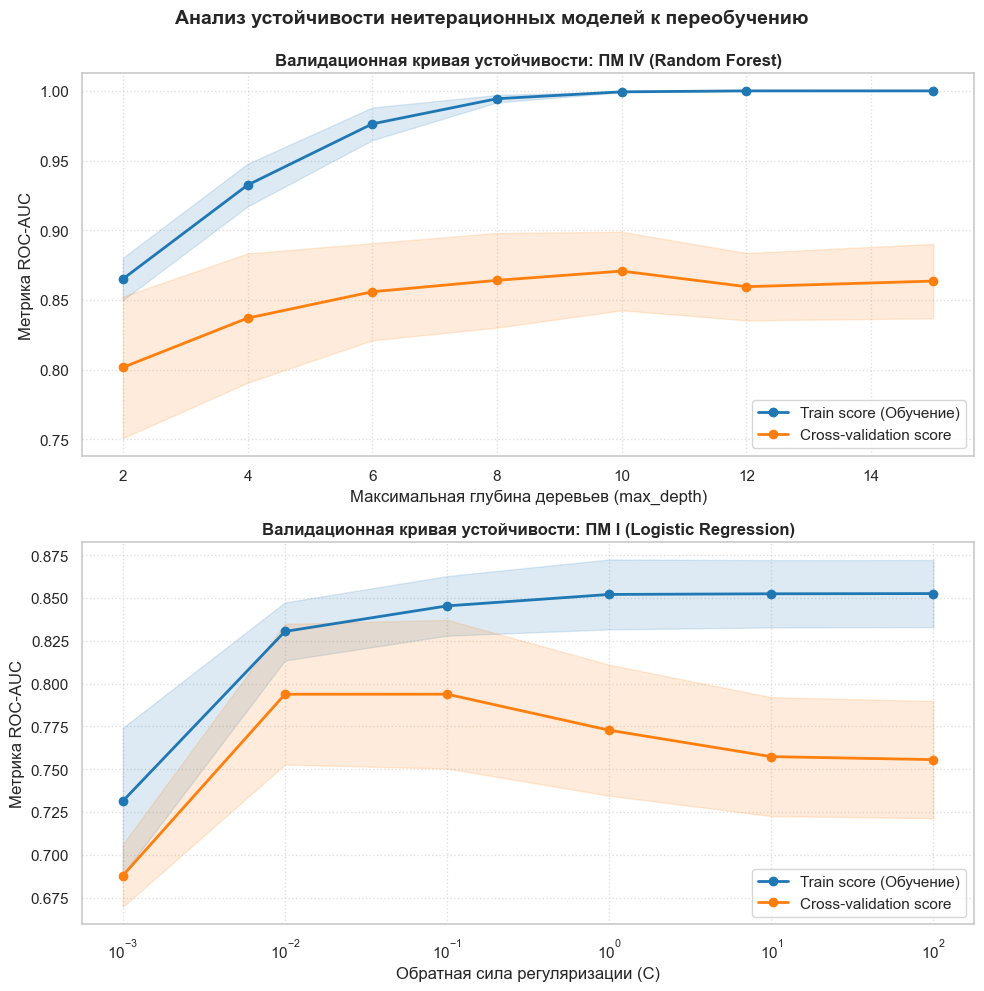

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Объединяем тренировочную и валидационную выборку только для функции validation_curve (она сама сделает внутренний сплит)
X_cv = np.vstack([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

# Настраиваем конфигурации для проверки сложности моделей
configs = [
    {
        'name': 'ПМ IV (Random Forest)',
        'model': ImbPipeline([('smote', SMOTE(random_state=42)), ('model', RandomForestClassifier(random_state=42))]),
        'param_name': 'model__max_depth',
        'param_range': [2, 4, 6, 8, 10, 12, 15],
        'xlabel': 'Максимальная глубина деревьев (max_depth)'
    },
    {
        'name': 'ПМ I (Logistic Regression)',
        'model': ImbPipeline([('smote', SMOTE(random_state=42)), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
        'param_name': 'model__C',
        'param_range': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'xlabel': 'Обратная сила регуляризации (C)'
    }
]

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for i, cfg in enumerate(configs):
    ax = axes[i]
    print(f"📊 Расчет валидационной кривой для {cfg['name']}...")
    
    train_scores, test_scores = validation_curve(
        cfg['model'], X_cv, y_cv,
        param_name=cfg['param_name'],
        param_range=cfg['param_range'],
        cv=3, scoring="roc_auc", n_jobs=-1
    )
    
    # Считаем среднее и стандартное отклонение
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # Отрисовка
    ax.plot(cfg['param_range'], train_mean, label="Train score (Обучение)", color="#1f77b4", lw=2, marker='o')
    ax.fill_between(cfg['param_range'], train_mean - train_std, train_mean + train_std, alpha=0.15, color="#1f77b4")
    
    ax.plot(cfg['param_range'], test_mean, label="Cross-validation score", color="#ff7f0e", lw=2, marker='o')
    ax.fill_between(cfg['param_range'], test_mean - test_std, test_mean + test_std, alpha=0.15, color="#ff7f0e")
    
    ax.set_title(f"Валидационная кривая устойчивости: {cfg['name']}", fontweight='bold', fontsize=12)
    ax.set_xlabel(cfg['xlabel'])
    ax.set_ylabel('Метрика ROC-AUC')
    
    if cfg['param_name'] == 'model__C':
        ax.set_xscale('log') # Для логистической регрессии шкалу С лучше сделать логарифмической
        
    ax.legend(loc="lower right")
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Анализ устойчивости неитерационных моделей к переобучению', y=0.99, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('non_iterative_validation_curves.png', dpi=300)
plt.show()


--- ШАГ 7: СБОР И ГЕНЕРАЦИЯ FEATURE IMPORTANCE ДЛЯ ВСЕХ МОДЕЛЕЙ ---

📊 СВОДНАЯ ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ ВСЕХ МОДЕЛЕЙ:
                     Признак ПМ I (LR, Coef) ПМ II (CatBoost, %) ПМ III (LGBM, %) ПМ IV (RF, %) ПМ V (XGBoost, %) Среднее ансамблей (%)
              Объем_операции           0.296              20.082           15.017        19.749            15.834                17.670
           Класс_стенокардии           0.199              17.540           10.012        10.496            14.963                13.253
              ОИМ_в_анамнезе           0.158              14.933            9.546        12.644            12.562                12.421
                          ЛГ           0.233               6.893            6.752        14.141            16.021                10.952
                     ФК_NYHA           0.277              10.258            8.731        14.241            10.263                10.873
     Нарушение_функции_почек           0.190               

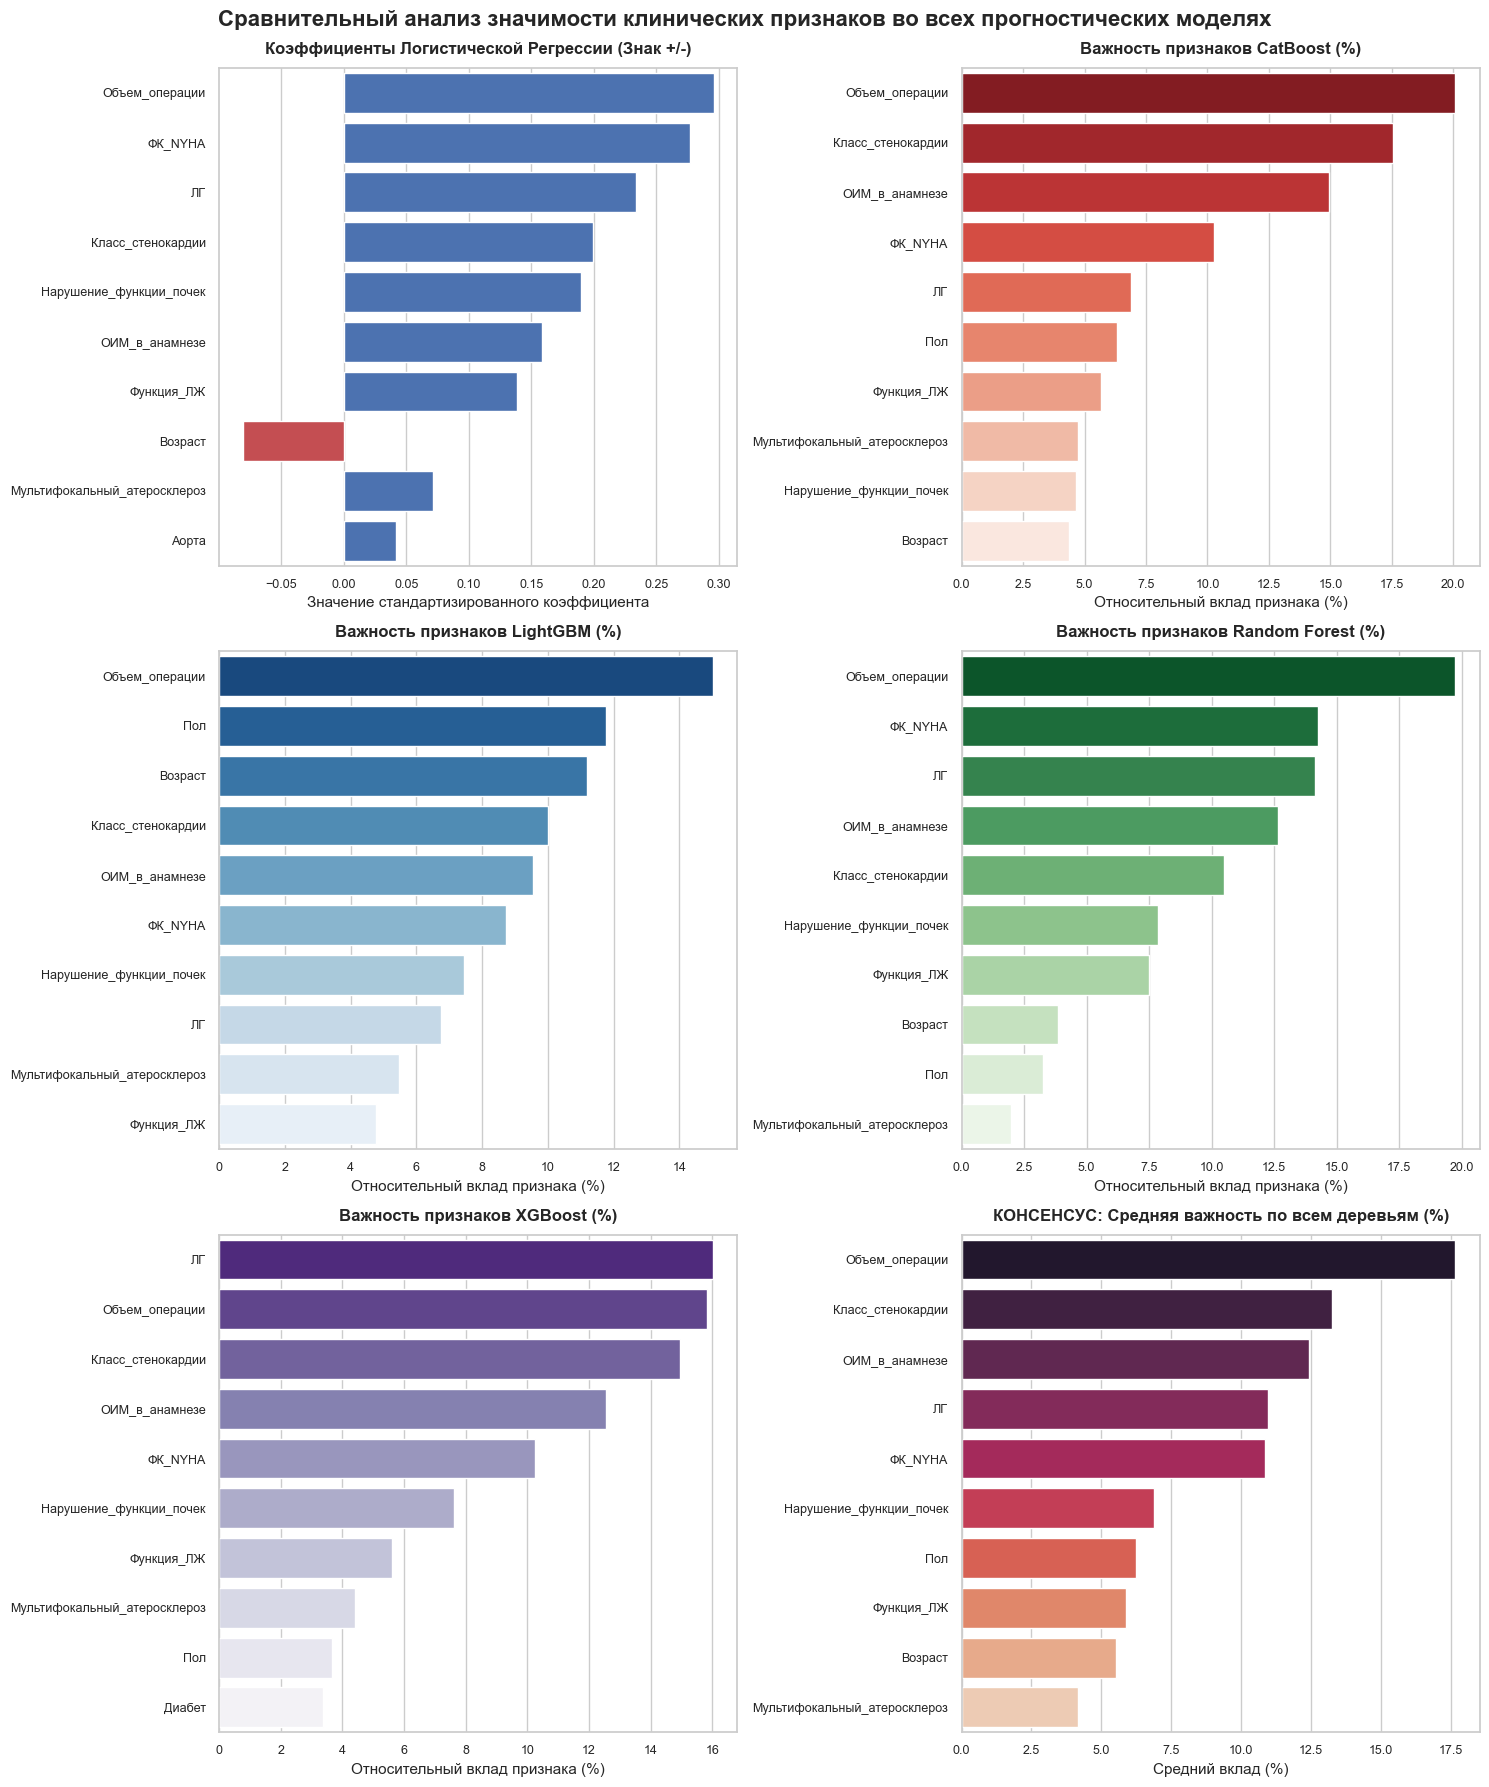

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Установка шрифтов и стилей для графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14
})

# Определение названий признаков
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f'Признак {i}' for i in range(X_train.shape[1])]

print("\n" + "="*80)
print("--- ШАГ 7: СБОР И ГЕНЕРАЦИЯ FEATURE IMPORTANCE ДЛЯ ВСЕХ МОДЕЛЕЙ ---")
print("="*80)

# =====================================================================
# 1. СБОР ДАННЫХ ИЗ ПАЙПЛАЙНОВ
# =====================================================================

# ПМ I (Логистическая регрессия) — берем коэффициенты
lr_coefs = final_pms['ПМ I (LR)'].named_steps['model'].coef_[0]

# Древесные модели — берем их внутренние скоры
cb_imp = final_pms['ПМ II (CatBoost)'].named_steps['model'].get_feature_importance()
lgb_imp = final_pms['ПМ III (LGBM)'].named_steps['model'].feature_importances_
rf_imp = final_pms['ПМ IV (RF)'].named_steps['model'].feature_importances_
xgb_imp = final_pms['ПМ V (XGBoost)'].named_steps['model'].feature_importances_

# =====================================================================
# 2. ПОСТРОЕНИЕ СВОДНОЙ ТАБЛИЦЫ
# =====================================================================
# Нормализуем древесные признаки в проценты (сумма = 100%), чтобы сравнение было эквивалентным
df_all_imp = pd.DataFrame({
    'Признак': feature_names,
    'ПМ I (LR, Coef)': lr_coefs,
    'ПМ II (CatBoost, %)': (cb_imp / np.sum(cb_imp)) * 100,
    'ПМ III (LGBM, %)': (lgb_imp / np.sum(lgb_imp)) * 100,
    'ПМ IV (RF, %)': (rf_imp / np.sum(rf_imp)) * 100,
    'ПМ V (XGBoost, %)': (xgb_imp / np.sum(xgb_imp)) * 100
})

# Считаем среднюю важность по всем 4 ансамблям для поиска консенсус-лидеров
df_all_imp['Среднее ансамблей (%)'] = df_all_imp[[
    'ПМ II (CatBoost, %)', 'ПМ III (LGBM, %)', 'ПМ IV (RF, %)', 'ПМ V (XGBoost, %)'
]].mean(axis=1)

# Сортируем по средней важности ансамблей
df_all_imp = df_all_imp.sort_values(by='Среднее ансамблей (%)', ascending=False)

print("\n📊 СВОДНАЯ ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ ВСЕХ МОДЕЛЕЙ:")
print(df_all_imp.to_string(index=False, formatters={f: '{:.3f}'.format for f in df_all_imp.columns if f != 'Признак'}))

# Сохраняем таблицу в CSV на случай, если её нужно будет перенести в Excel/Word
df_all_imp.to_csv('all_models_feature_importance.csv', index=False, encoding='utf-8-sig')
print("\n💾 Таблица сохранена в файл: 'all_models_feature_importance.csv'")

# =====================================================================
# 3. ВИЗУАЛИЗАЦИЯ: МАТРИЦА ГРАФИКОВ (SUBPLOTS 3x2)
# =====================================================================
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten() # Превращаем матрицу в плоский массив для легкой итерации

# Топ-10 для отображения на графиках
top_n = 10

# Настройки для каждого подграфика (Модель, колонка в DF, название графика, палитра, тип данных)
plot_configs = [
    ('ПМ I (LR)', 'ПМ I (LR, Coef)', 'Коэффициенты Логистической Регрессии (Знак +/-)', 'coolwarm', 'coef'),
    ('ПМ II (CatBoost)', 'ПМ II (CatBoost, %)', 'Важность признаков CatBoost (%)', 'Reds_r', 'tree'),
    ('ПМ III (LGBM)', 'ПМ III (LGBM, %)', 'Важность признаков LightGBM (%)', 'Blues_r', 'tree'),
    ('ПМ IV (RF)', 'ПМ IV (RF, %)', 'Важность признаков Random Forest (%)', 'Greens_r', 'tree'),
    ('ПМ V (XGBoost)', 'ПМ V (XGBoost, %)', 'Важность признаков XGBoost (%)', 'Purples_r', 'tree')
]

for i, (model_name, col, title, palette, m_type) in enumerate(plot_configs):
    ax = axes[i]
    
    if m_type == 'coef':
        # Для линейной модели сортируем по абсолютному значению, но строим реальные веса
        sub_df = df_all_imp.copy()
        sub_df['abs_val'] = sub_df[col].abs()
        sub_df = sub_df.sort_values(by='abs_val', ascending=False).head(top_n)
        
        # Горизонтальный барплот со знаками
        colors = ['#4c72b0' if x > 0 else '#c44e52' for x in sub_df[col]]
        sns.barplot(data=sub_df, x=col, y='Признак', ax=ax, palette=None, color=None)
        # Красим бары вручную в зависимости от знака влияния
        for bar, color in zip(ax.patches, colors):
            bar.set_facecolor(color)
        ax.set_xlabel('Значение стандартизированного коэффициента')
    
    else:
        # Для древесных моделей просто берем топ-10 по значению
        sub_df = df_all_imp.sort_values(by=col, ascending=False).head(top_n)
        sns.barplot(data=sub_df, x=col, y='Признак', ax=ax, palette=palette)
        ax.set_xlabel('Относительный вклад признака (%)')
        
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylabel('')

# 6-й сабплот (пустой) используем под общую легенду или консенсус-график
ax_last = axes[5]
sub_df_mean = df_all_imp.sort_values(by='Среднее ансамблей (%)', ascending=False).head(top_n)
sns.barplot(data=sub_df_mean, x='Среднее ансамблей (%)', y='Признак', ax=ax_last, palette='rocket')
ax_last.set_title('КОНСЕНСУС: Средняя важность по всем деревьям (%)', fontweight='bold', pad=10)
ax_last.set_xlabel('Средний вклад (%)')
ax_last.set_ylabel('')

# Финализация графиков
plt.suptitle('Сравнительный анализ значимости клинических признаков во всех прогностических моделях', y=0.99, fontsize=16, fontweight='bold')
plt.tight_layout()

# Сохраняем тяжелый качественный рисунок для вставки в диссертацию
plt.savefig('all_models_feature_importance.png', dpi=300, bbox_inches='tight')
print("🖼️ Матрица графиков сохранена как 'all_models_feature_importance.png'")
plt.show()


--- ШАГ 7: СБОР И ГЕНЕРАЦИЯ FEATURE IMPORTANCE ДЛЯ ВСЕХ МОДЕЛЕЙ (ВКЛЮЧАЯ SVM) ---
⏳ Расчет Permutation Importance для ПМ VI (SVM)... Это может занять немного времени.

📊 СВОДНАЯ ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ ВСЕХ МОДЕЛЕЙ (ВКЛЮЧАЯ SVM):
                     Признак ПМ I (LR, Coef) ПМ II (CatBoost, %) ПМ III (LGBM, %) ПМ IV (RF, %) ПМ V (XGBoost, %) ПМ VI (SVM, %) Консенсус-важность (%)
              Объем_операции           0.296              20.082           15.017        19.749            15.834         15.873                 17.311
           Класс_стенокардии           0.199              17.540           10.012        10.496            14.963         16.298                 13.862
                     ФК_NYHA           0.277              10.258            8.731        14.241            10.263         21.032                 12.905
                          ЛГ           0.233               6.893            6.752        14.141            16.021          9.042                 10.570
  

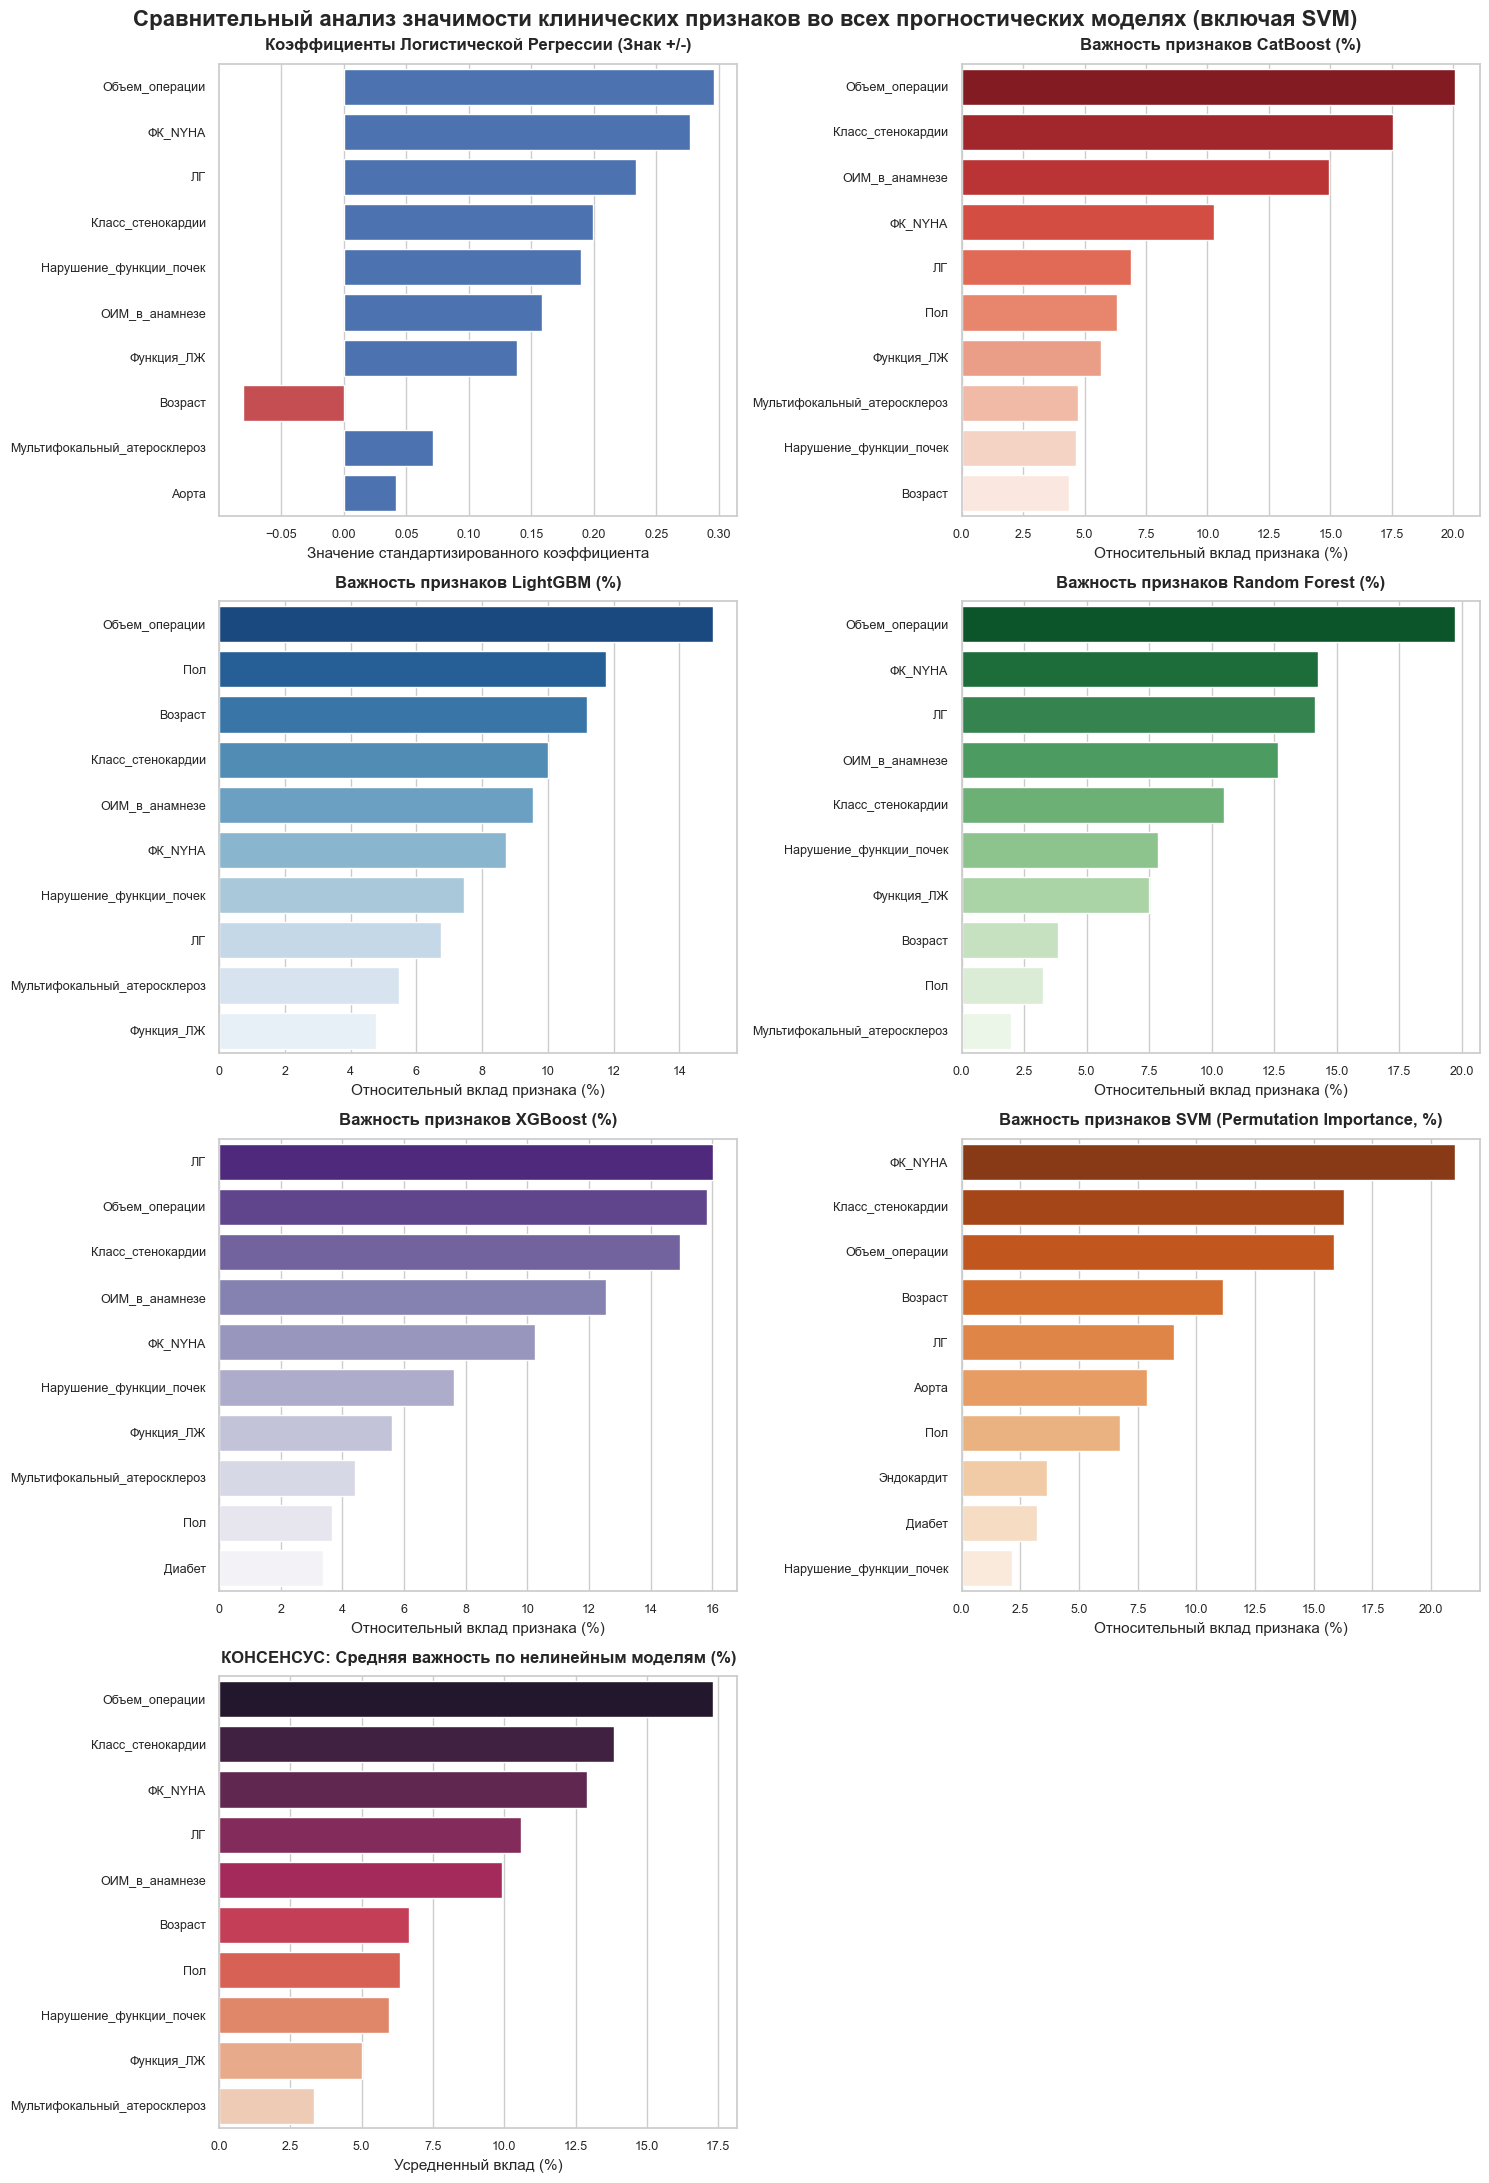

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Импортируем инструмент для расчета нелинейной важности SVM
from sklearn.inspection import permutation_importance 

warnings.filterwarnings('ignore')

# Установка шрифтов и стилей для графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14
})

# Определение названий признаков
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f'Признак {i}' for i in range(X_train.shape[1])]

print("\n" + "="*80)
print("--- ШАГ 7: СБОР И ГЕНЕРАЦИЯ FEATURE IMPORTANCE ДЛЯ ВСЕХ МОДЕЛЕЙ (ВКЛЮЧАЯ SVM) ---")
print("="*80)

# =====================================================================
# 1. СБОР ДАННЫХ ИЗ ПАЙПЛАЙНОВ
# =====================================================================

# ПМ I (Логистическая регрессия) — берем коэффициенты
lr_coefs = final_pms['ПМ I (LR)'].named_steps['model'].coef_[0]

# Древесные модели — берем их внутренние скоры
cb_imp = final_pms['ПМ II (CatBoost)'].named_steps['model'].get_feature_importance()
lgb_imp = final_pms['ПМ III (LGBM)'].named_steps['model'].feature_importances_
rf_imp = final_pms['ПМ IV (RF)'].named_steps['model'].feature_importances_
xgb_imp = final_pms['ПМ V (XGBoost)'].named_steps['model'].feature_importances_

# ПМ VI (SVM) — Расчет Permutation Importance (так как у RBF-ядра нет прямых коэффициентов)
print("⏳ Расчет Permutation Importance для ПМ VI (SVM)... Это может занять немного времени.")
svm_pipeline = final_pms['ПМ VI (SVM)']
# Считаем на валидационной/тестовой выборке, чтобы оценить реальное влияние на обобщающую способность
perm_result = permutation_importance(
    svm_pipeline, X_val, y_val, 
    scoring='roc_auc', 
    n_repeats=10, 
    random_state=42, 
    n_jobs=None
)
# Берем среднее значение падения метрики для каждого признака
svm_imp = perm_result.importances_mean
# Зануляем случайные отрицательные значения (которые могут возникнуть у шумовых признаков)
svm_imp = np.maximum(svm_imp, 0)

# =====================================================================
# 2. ПОСТРОЕНИЕ СВОДНОЙ ТАБЛИЦЫ
# =====================================================================
# Нормализуем все нелинейные признаки в проценты (сумма = 100%), чтобы сравнение было эквивалентным
df_all_imp = pd.DataFrame({
    'Признак': feature_names,
    'ПМ I (LR, Coef)': lr_coefs,
    'ПМ II (CatBoost, %)': (cb_imp / np.sum(cb_imp)) * 100,
    'ПМ III (LGBM, %)': (lgb_imp / np.sum(lgb_imp)) * 100,
    'ПМ IV (RF, %)': (rf_imp / np.sum(rf_imp)) * 100,
    'ПМ V (XGBoost, %)': (xgb_imp / np.sum(xgb_imp)) * 100,
    'ПМ VI (SVM, %)': (svm_imp / np.sum(svm_imp)) * 100 if np.sum(svm_imp) > 0 else svm_imp
})

# Считаем среднюю консенсус-важность по всем 5 нелинейным моделям (Ансамбли + SVM)
non_linear_cols = [
    'ПМ II (CatBoost, %)', 'ПМ III (LGBM, %)', 
    'ПМ IV (RF, %)', 'ПМ V (XGBoost, %)', 'ПМ VI (SVM, %)'
]
df_all_imp['Консенсус-важность (%)'] = df_all_imp[non_linear_cols].mean(axis=1)

# Сортируем по финальной консенсус-важности
df_all_imp = df_all_imp.sort_values(by='Консенсус-важность (%)', ascending=False)

print("\n📊 СВОДНАЯ ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ ВСЕХ МОДЕЛЕЙ (ВКЛЮЧАЯ SVM):")
print(df_all_imp.to_string(index=False, formatters={f: '{:.3f}'.format for f in df_all_imp.columns if f != 'Признак'}))

# Сохраняем таблицу в CSV для Excel/Word
df_all_imp.to_csv('all_models_feature_importance.csv', index=False, encoding='utf-8-sig')
print("\n💾 Таблица сохранена в файл: 'all_models_feature_importance.csv'")

# =====================================================================
# 3. ВИЗУАЛИЗАЦИЯ: МАТРИЦА ГРАФИКОВ (SUBPLOTS 4x2)
# =====================================================================
# Увеличиваем сетку до 4 строк и 2 колонок (всего 8 слотов), чтобы красиво вместить 6 моделей и 1 консенсус
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 22))
axes = axes.flatten() 

# Топ-n признаков для отображения на графиках
top_n = 10

# Настройки конфигурации графиков для каждой модели
plot_configs = [
    ('ПМ I (LR)', 'ПМ I (LR, Coef)', 'Коэффициенты Логистической Регрессии (Знак +/-)', 'coolwarm', 'coef'),
    ('ПМ II (CatBoost)', 'ПМ II (CatBoost, %)', 'Важность признаков CatBoost (%)', 'Reds_r', 'non_linear'),
    ('ПМ III (LGBM)', 'ПМ III (LGBM, %)', 'Важность признаков LightGBM (%)', 'Blues_r', 'non_linear'),
    ('ПМ IV (RF)', 'ПМ IV (RF, %)', 'Важность признаков Random Forest (%)', 'Greens_r', 'non_linear'),
    ('ПМ V (XGBoost)', 'ПМ V (XGBoost, %)', 'Важность признаков XGBoost (%)', 'Purples_r', 'non_linear'),
    ('ПМ VI (SVM)', 'ПМ VI (SVM, %)', 'Важность признаков SVM (Permutation Importance, %)', 'Oranges_r', 'non_linear')
]

for i, (model_name, col, title, palette, m_type) in enumerate(plot_configs):
    ax = axes[i]
    
    if m_type == 'coef':
        # Для линейной модели сортируем по абсолютному значению
        sub_df = df_all_imp.copy()
        sub_df['abs_val'] = sub_df[col].abs()
        sub_df = sub_df.sort_values(by='abs_val', ascending=False).head(top_n)
        
        colors = ['#4c72b0' if x > 0 else '#c44e52' for x in sub_df[col]]
        sns.barplot(data=sub_df, x=col, y='Признак', ax=ax)
        
        # Красим бары вручную (синий — риск растет, красный — риск падает)
        for bar, color in zip(ax.patches, colors):
            bar.set_facecolor(color)
        ax.set_xlabel('Значение стандартизированного коэффициента')
    
    else:
        # Для нелинейных моделей (деревья и SVM) берем топ-10 по значению
        sub_df = df_all_imp.sort_values(by=col, ascending=False).head(top_n)
        sns.barplot(data=sub_df, x=col, y='Признак', ax=ax, palette=palette)
        ax.set_xlabel('Относительный вклад признака (%)')
        
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylabel('')

# 7-й сабплот отдаем под итоговый КОНСЕНСУС
ax_consensus = axes[6]
sub_df_mean = df_all_imp.sort_values(by='Консенсус-важность (%)', ascending=False).head(top_n)
sns.barplot(data=sub_df_mean, x='Консенсус-важность (%)', y='Признак', ax=ax_consensus, palette='rocket')
ax_consensus.set_title('КОНСЕНСУС: Средняя важность по нелинейным моделям (%)', fontweight='bold', pad=10)
ax_consensus.set_xlabel('Усредненный вклад (%)')
ax_consensus.set_ylabel('')

# 8-й сабплот (оставшийся пустым) мы просто отключаем, чтобы график выглядел аккуратно
axes[7].axis('off')

# Финализация графиков
plt.suptitle('Сравнительный анализ значимости клинических признаков во всех прогностических моделях (включая SVM)', y=0.99, fontsize=16, fontweight='bold')
plt.tight_layout()

# Сохраняем тяжелый качественный рисунок для диссертации
plt.savefig('all_models_feature_importance.png', dpi=300, bbox_inches='tight')
print("🖼️ Матрица графиков сохранена как 'all_models_feature_importance.png'")
plt.show()

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Настройка названий признаков
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns.tolist()
    # Создадим копию данных для SHAP, чтобы графики имели красивые текстовые названия колонок
    X_test_df = pd.DataFrame(X_test, columns=feature_names)
else:
    feature_names = [f'Признак {i}' for i in range(X_train.shape[1])]
    X_test_df = pd.DataFrame(X_test, columns=feature_names)

print("\n" + "="*80)
print("--- ШАГ 8: ГЛУБОКИЙ SHAP-АНАЛИЗ ДЛЯ ВСЕХ МОДЕЛЕЙ (ИЗОЛИРОВАННЫЙ ТЕСТ) ---")
print("="*80)

# Словарь для сохранения посчитанных shap-значений (пригодится для кастомных графиков)
shap_values_dict = {}

# =====================================================================
# 1. SHAP ДЛЯ ПМ I (Логистическая регрессия) — LinearExplainer
# =====================================================================
print("🔮 Расчет SHAP для ПМ I (Logistic Regression)...")
lr_pipeline = final_pms['ПМ I (LR)']
# ВАЖНО: Линейная модель обучалась на отмасштабированных данных! 
# Чтобы интерпретация была корректной, берем шаг scaler и трансформацию данных
X_test_scaled = lr_pipeline.named_steps['scaler'].transform(X_test_df)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

lr_model = lr_pipeline.named_steps['model']
explainer_lr = shap.LinearExplainer(lr_model, X_test_scaled_df)
shap_values_dict['ПМ I (LR)'] = explainer_lr(X_test_scaled_df)

# =====================================================================
# 2. SHAP ДЛЯ ДРЕВЕСНЫХ АНСАМБЛЕЙ — TreeExplainer
# =====================================================================
# Для деревьев масштабирование не нужно, передаем чистый X_test_df

# ПМ II (CatBoost)
print("🔮 Расчет SHAP для ПМ II (CatBoost)...")
cb_model = final_pms['ПМ II (CatBoost)'].named_steps['model']
explainer_cb = shap.TreeExplainer(cb_model)
shap_values_dict['ПМ II (CatBoost)'] = explainer_cb(X_test_df)

# ПМ III (LGBM)
print("🔮 Расчет SHAP для ПМ III (LGBM)...")
lgb_model = final_pms['ПМ III (LGBM)'].named_steps['model']
explainer_lgb = shap.TreeExplainer(lgb_model)
shap_values_dict['ПМ III (LGBM)'] = explainer_lgb(X_test_df)

# ПМ IV (Random Forest)
print("🔮 Расчет SHAP для ПМ IV (RF)...")
rf_model = final_pms['ПМ IV (RF)'].named_steps['model']
explainer_rf = shap.TreeExplainer(rf_model)
# У случайного леса на выходе вероятности для каждого класса (массив из 2 элементов). 
# Нам нужен срез по положительному классу [..., 1]
rf_shap = explainer_rf.shap_values(X_test_df)
if isinstance(rf_shap, list): # В зависимости от версии shap формат может меняться
    shap_values_dict['ПМ IV (RF)'] = explainer_rf(X_test_df)[..., 1]
else:
    shap_values_dict['ПМ IV (RF)'] = explainer_rf(X_test_df)[..., 1]

# ПМ V (XGBoost)
print("🔮 Расчет SHAP для ПМ V (XGBoost)...")
xgb_model = final_pms['ПМ V (XGBoost)'].named_steps['model']
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_dict['ПМ V (XGBoost)'] = explainer_xgb(X_test_df)

print("✅ Все SHAP-значения успешно рассчитаны!")

# =====================================================================
# 3. ГЕНЕРАЦИЯ И СОХРАНЕНИЕ ИНДИВИДУАЛЬНЫХ ГРАФИКОВ SUMMARY PLOT
# =====================================================================
print("\n🖼️ Отрисовка и сохранение графиков SHAP Summary Plots...")

for model_name, shap_vals in shap_values_dict.items():
    plt.figure(figsize=(10, 6))
    
    # Заголовок для графика
    plt.title(f'Влияние признаков на прогноз риска неблагоприятного исхода ({model_name})', fontsize=12, pad=15)
    
    # Строим график. Для линейной модели передаем масштабированный датасет, для остальных — исходный
    current_x = X_test_scaled_df if model_name == 'ПМ I (LR)' else X_test_df
    
    shap.summary_plot(shap_vals, current_x, max_display=10, show=False)
    
    plt.tight_layout()
    filename = f'shap_summary_{model_name.replace(" ", "_").replace("(", "").replace(")", "")}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"💾 График для {model_name} сохранен как '{filename}'")

print("\n🎉 SHAP-анализ полностью завершен! Все графики лежат в папке проекта.")


--- ШАГ 8: ГЛУБОКИЙ SHAP-АНАЛИЗ ДЛЯ ВСЕХ МОДЕЛЕЙ (ИЗОЛИРОВАННЫЙ ТЕСТ) ---
🔮 Расчет SHAP для ПМ I (Logistic Regression)...
🔮 Расчет SHAP для ПМ II (CatBoost)...
🔮 Расчет SHAP для ПМ III (LGBM)...
🔮 Расчет SHAP для ПМ IV (RF)...
🔮 Расчет SHAP для ПМ V (XGBoost)...
✅ Все SHAP-значения успешно рассчитаны!

🖼️ Отрисовка и сохранение графиков SHAP Summary Plots...
💾 График для ПМ I (LR) сохранен как 'shap_summary_ПМ_I_LR.png'
💾 График для ПМ II (CatBoost) сохранен как 'shap_summary_ПМ_II_CatBoost.png'
💾 График для ПМ III (LGBM) сохранен как 'shap_summary_ПМ_III_LGBM.png'
💾 График для ПМ IV (RF) сохранен как 'shap_summary_ПМ_IV_RF.png'
💾 График для ПМ V (XGBoost) сохранен как 'shap_summary_ПМ_V_XGBoost.png'

🎉 SHAP-анализ полностью завершен! Все графики лежат в папке проекта.


🔮 ИЗОЛИРОВАННЫЙ РАСЧЕТ SHAP ДЛЯ ПМ VI (SVM) — ИСПРАВЛЕННАЯ ВЕРСИЯ
⏳ Группировка данных методом k-means...
⏳ Вычисление SHAP-значений (это может занять от 30 секунд до пары минут)...


  0%|          | 0/81 [00:00<?, ?it/s]

📊 Контроль размерностей: Матрица SHAP (81, 14) == Матрица признаков (81, 14)


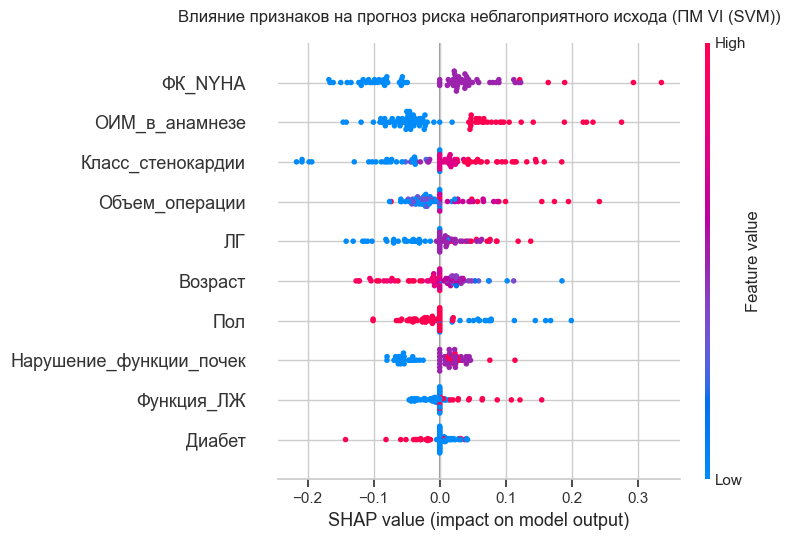

💾 Расчет завершен! График выведен на экран и успешно сохранен как 'shap_summary_ПМ_VI_SVM.png'


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# 1. Подготовка названий признаков и датафрейма
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns.tolist()
    X_test_df = pd.DataFrame(X_test, columns=feature_names)
else:
    feature_names = [f'Признак {i}' for i in range(X_train.shape[1])]
    X_test_df = pd.DataFrame(X_test, columns=feature_names)

print("="*80)
print("🔮 ИЗОЛИРОВАННЫЙ РАСЧЕТ SHAP ДЛЯ ПМ VI (SVM) — ИСПРАВЛЕННАЯ ВЕРСИЯ")
print("="*80)

# 2. Извлечение пайплайна и масштабирование данных (Критично для SVM!)
svm_pipeline = final_pms['ПМ VI (SVM)']
X_test_svm_scaled = svm_pipeline.named_steps['scaler'].transform(X_test_df)
X_test_svm_scaled_df = pd.DataFrame(X_test_svm_scaled, columns=feature_names)

svm_model = svm_pipeline.named_steps['model']

# 3. Сжатие фонового датасета через k-means до 50 центроид для ускорения расчета
print("⏳ Группировка данных методом k-means...")
background_summary = shap.kmeans(X_test_svm_scaled_df, 50) 

# 4. Инициализация KernelExplainer на основе функции предсказания вероятностей
explainer_svm = shap.KernelExplainer(svm_model.predict_proba, background_summary)

# 5. Расчет сырых SHAP-значений для тестовой выборки
print("⏳ Вычисление SHAP-значений (это может занять от 30 секунд до пары минут)...")
svm_shap_raw = explainer_svm.shap_values(X_test_svm_scaled_df)

# 6. Робастное выравнивание размерностей матрицы (Защита от AssertionError)
if isinstance(svm_shap_raw, list):
    # Если вернулся список матриц [класс_0, класс_1]
    svm_shap_values = svm_shap_raw[1]
elif isinstance(svm_shap_raw, np.ndarray) and len(svm_shap_raw.shape) == 3:
    # Если вернулся трехмерный тензор (пациенты, признаки, классы)
    svm_shap_values = svm_shap_raw[:, :, 1]
else:
    # Если вернулась готовая двумерная матрица (пациенты, признаки)
    svm_shap_values = svm_shap_raw

# 7. Финальная проверка того, что размерности строго совпали перед отрисовкой
print(f"📊 Контроль размерностей: Матрица SHAP {svm_shap_values.shape} == Матрица признаков {X_test_svm_scaled_df.shape}")

# 8. Отрисовка, вывод на экран и сохранение summary_plot
plt.figure(figsize=(10, 6))
plt.title('Влияние признаков на прогноз риска неблагоприятного исхода (ПМ VI (SVM))', fontsize=12, pad=15)

# Передаем проверенные выровненные переменные
shap.summary_plot(svm_shap_values, X_test_svm_scaled_df, max_display=10, show=False)

plt.tight_layout()
filename = 'shap_summary_ПМ_VI_SVM.png'

# Сохраняем в файл высокого разрешения и принудительно отображаем в интерфейсе
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"💾 Расчет завершен! График выведен на экран и успешно сохранен как '{filename}'")

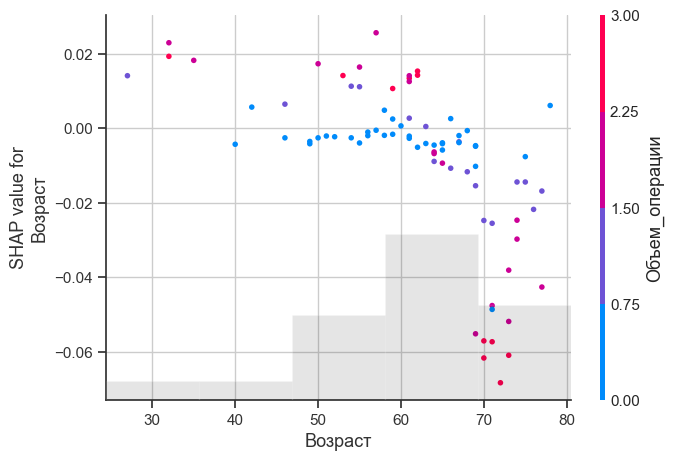

In [59]:
import shap

# 1. Извлекаем саму модель из пайплайна
best_model = final_pms['ПМ IV (RF)'][-1] 

# 2. Инициализируем эксплейнер
explainer = shap.TreeExplainer(best_model)

# 3. Рассчитываем shap_values
shap_values = explainer(X_test_df)

# Проверяем размерность. Если на конце стоит цифра 2, значит посчитано для двух классов.
# Нам нужен класс [:, :, 1] (риск летального исхода).
if len(shap_values.shape) == 3 and shap_values.shape[-1] == 2:
    shap_values_target = shap_values[:, :, 1]
else:
    shap_values_target = shap_values

# 4. Строим график с правильным срезом по признаку и по автоматическому выбору цвета
# Теперь передаем одномерный срез для "Функции_ЛЖ", а в color отдаем весь очищенный объект
shap.plots.scatter(shap_values_target[:, "Возраст"], color=shap_values_target)

In [60]:
import numpy as np
import pandas as pd
import shap

# 1. Рассчитываем матрицу взаимодействий (внимание: для больших выборок может занять время)
# На выходе получаем массив размерности (субъекты, признаки, признаки)
interaction_values = shap.TreeExplainer(model).shap_interaction_values(X_test)

# 2. Находим индекс интересующего нас признака (например, "Возраст")
feature_name = "Возраст"
feature_idx = list(X_test.columns).index(feature_name)

# 3. Считаем среднее абсолютное значение взаимодействия этого признака со всеми остальными
mean_interactions = np.abs(interaction_values[:, feature_idx, :]).mean(axis=0)

# 4. Оформляем в красивую таблицу
df_interactions = pd.DataFrame({
    'Признак': X_test.columns,
    'Сила взаимодействия': mean_interactions
})

# Исключаем взаимодействие признака самого с собой (это его чистое линейное влияние)
df_interactions = df_interactions[df_interactions['Признак'] != feature_name]
df_interactions = df_interactions.sort_values(by='Сила взаимодействия', ascending=False)

print(f"📊 Топ признаков, взаимодействующих с параметром '{feature_name}':")
print(df_interactions.head(5).to_string(index=False))

📊 Топ признаков, взаимодействующих с параметром 'Возраст':
                Признак  Сила взаимодействия
         Объем_операции             0.067168
                    Пол             0.048526
                     ЛГ             0.040490
             Функция_ЛЖ             0.038700
Нарушение_функции_почек             0.037932
